# Hybrid DenseNet121–ViT-B/16 with Cross-Attention Fusion for Binary Melanoma Classification
### ISIC 2019 & 2020 Melanoma Dataset (Melanoma vs. Nevus) — DenseNet121 + ViT-B/16 + Cross-Attention

**Dataset:** [ISIC 2019 & 2020 Melanoma Dataset](https://www.kaggle.com/datasets/qikangdeng/isic-2019-and-2020-melanoma-dataset)
(binary subset of the ISIC archive: `mel` = melanoma, `nevus` = benign nevus)

**Pipeline overview**

1. Data Preparation (loading, splitting, augmentation, visualization)
2. Hybrid Architecture (DenseNet121 CNN + ViT-B/16 Transformer + Cross-Attention Fusion)
3. Training (AdamW, LR scheduling, early stopping, AMP, checkpointing)
4. Evaluation (full clinical-grade binary metric suite, melanoma = positive class)
5. Visualization (curves, confusion matrices, ROC/PR curves)
6. Explainable AI (Grad-CAM)
7. Feature Visualization (t-SNE, UMAP)
8. Error Analysis
9. Model Summary
10. Results Saving

> **Note on dataset structure:** This dataset ships as a **flat binary** layout — just two
> class folders (`mel/`, `nevus/`) with **no pre-made Train/Test split** and no metadata CSV.
> We therefore build the **entire Train/Validation/Test split ourselves** in Part 1, using a
> stratified 70/15/15 split so the rare melanoma class is proportionally represented in every
> split. Because this is now a **binary clinical screening problem**, `mel` (melanoma) is
> treated as the positive class throughout Part 4's metrics — this matters for Sensitivity,
> Specificity, ROC-AUC, and PR-AUC, since in melanoma screening false negatives (missing a
> melanoma) are far more costly than false positives.


## Part 0 — Environment Setup

Install/import all required libraries.

> **Kaggle GPU compatibility note:** Kaggle sometimes allocates a **Tesla P100** (Pascal
> architecture, compute capability 6.0). Recent PyTorch builds compiled for Ampere/Hopper
> drop Pascal support, causing `AcceleratorError: no kernel image for device`. The **first
> cell below auto-detects this and reinstalls a P100-compatible PyTorch (cu118) + restarts
> the kernel**. If you're on a T4 or A100, the cell does nothing.
> **After the kernel restarts, run all cells again from the top.**


In [1]:
# ----------------------------- PyTorch / CUDA compatibility fix for Kaggle P100 -----------------------------
# The default PyTorch build on Kaggle may be compiled for newer GPU architectures (Ampere/Hopper)
# and drop support for Pascal (P100, compute capability 6.0), causing:
#   AcceleratorError: CUDA error: no kernel image is available for execution on the device
#
# Fix: reinstall PyTorch with cu118 wheels, which explicitly support Pascal (sm_60).
# This runs only when a P100 is detected, so it's a no-op on T4/A100.
import subprocess, sys, torch

def _get_gpu_name():
    try:
        return torch.cuda.get_device_name(0) if torch.cuda.is_available() else ""
    except Exception:
        return ""

_gpu = _get_gpu_name()
print(f"Detected GPU: {_gpu or 'None'}")

if "P100" in _gpu or "Tesla P" in _gpu:
    print("P100 detected -- reinstalling PyTorch with cu118 wheels (Pascal-compatible)...")
    subprocess.run([
        sys.executable, "-m", "pip", "install", "-q", "--upgrade",
        "torch==2.1.2+cu118",
        "torchvision==0.16.2+cu118",
        "--extra-index-url", "https://download.pytorch.org/whl/cu118",
    ], check=False)
    print("Done. Kernel will now restart automatically to load the new PyTorch...")
    # Restart kernel so the new torch is actually loaded into memory
    import IPython
    IPython.Application.instance().kernel.do_shutdown(restart=True)
else:
    print("GPU is compatible -- no PyTorch reinstall needed.")


Detected GPU: Tesla T4
GPU is compatible -- no PyTorch reinstall needed.


In [2]:
# Quiet installation of packages that are NOT preinstalled in the Kaggle environment.
# torch / torchvision / sklearn / opencv / pandas / numpy / matplotlib / seaborn / tqdm
# are already available in the Kaggle base image, so we don't reinstall them.
import sys, subprocess

def pip_install(pkg):
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", pkg], check=False)

for _pkg in ["grad-cam", "umap-learn"]:
    pip_install(_pkg)

print("Package installation step complete.")


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 78.8 MB/s eta 0:00:00
Package installation step complete.


In [3]:
# ----------------------------- Core imports -----------------------------
import os
import gc
import time
import json
import random
import shutil
import warnings
from pathlib import Path
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

# ----------------------------- PyTorch -----------------------------
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split
from torch.optim import AdamW
from torch.optim.lr_scheduler import ReduceLROnPlateau
from torch.amp import autocast, GradScaler

import torchvision
from torchvision import transforms, models
from torchvision.models import DenseNet121_Weights, ResNet50_Weights

from IPython.display import display

# ----------------------------- sklearn -----------------------------
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    balanced_accuracy_score, roc_auc_score, average_precision_score,
    matthews_corrcoef, cohen_kappa_score, confusion_matrix,
    classification_report, roc_curve, precision_recall_curve
)
from sklearn.manifold import TSNE

# ----------------------------- Explainability / dim-reduction -----------------------------
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
import umap

warnings.filterwarnings("ignore")

# ----------------------------- OpenCV thread-pool safety -----------------------------
# cv2 spins up its own internal thread pool by default. Under fork()-based multiprocessing
# (DataLoader workers) and alongside PyTorch's own threading, this can cause slow memory
# growth / contention across worker processes. We disable it globally since cv2 is only used
# here for occasional visualization (not inside the per-sample Dataset hot path).
cv2.setNumThreads(0)

# ----------------------------- Reproducibility -----------------------------
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = False   # keep False for cuDNN autotuner speed
torch.backends.cudnn.benchmark = True

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")


Using device: cuda
GPU: Tesla T4


### Global Configuration & Output Folder Structure

All hyperparameters live in one `CONFIG` dictionary so the whole notebook is easy to re-run
with different settings. We also build the full `results/` directory tree required by the
project spec up front, so every later section can save into it without extra boilerplate.


In [4]:
# ----------------------------- Paths -----------------------------
# Kaggle mounts datasets under /kaggle/input/<dataset-slug>/...
# The "ISIC 2019 & 2020 Melanoma" (binary) dataset extracts to a flat structure:
#   /kaggle/input/.../isic-2019-and-2020-melanoma-dataset/isic19_20/mel/*.jpg
#   /kaggle/input/.../isic-2019-and-2020-melanoma-dataset/isic19_20/nevus/*.jpg
# NOTE: unlike the 9-class ISIC dataset, this one ships with NO pre-made Train/Test split --
# both classes sit directly under isic19_20/. We therefore create the ENTIRE
# Train/Validation/Test split ourselves in Part 1 (70/15/15, stratified).
# We search for it dynamically so the notebook still runs if Kaggle changes the exact nesting.

KAGGLE_INPUT_ROOT = Path("/kaggle/input")

EXPECTED_CLASS_DIRS = {"mel", "nevus"}

def find_dataset_root(input_root: Path):
    '''Locate the directory that directly contains the 'mel' and 'nevus' class subfolders.'''
    if not input_root.exists():
        return None
    for candidate in input_root.rglob("*"):
        if candidate.is_dir():
            children = {c.name.lower() for c in candidate.iterdir() if c.is_dir()}
            if EXPECTED_CLASS_DIRS.issubset(children):
                return candidate
    return None

DATASET_ROOT = find_dataset_root(KAGGLE_INPUT_ROOT)

if DATASET_ROOT is None:
    # Fallback for local / non-Kaggle runs -- adjust this path if running outside Kaggle.
    DATASET_ROOT = Path("./isic19_20")
    print("WARNING: Could not auto-locate dataset under /kaggle/input. "
          f"Falling back to local path: {DATASET_ROOT}")
else:
    print(f"Dataset root found: {DATASET_ROOT}")

# Resolve actual casing of class directories (Kaggle datasets are case-sensitive on disk)
def resolve_subdir(root: Path, name: str) -> Path:
    for child in root.iterdir():
        if child.is_dir() and child.name.lower() == name.lower():
            return child
    raise FileNotFoundError(f"Could not find a '{name}' folder under {root}")

MEL_DIR = resolve_subdir(DATASET_ROOT, "mel")
NEVUS_DIR = resolve_subdir(DATASET_ROOT, "nevus")

print(f"Melanoma directory: {MEL_DIR}")
print(f"Nevus directory:    {NEVUS_DIR}")


Dataset root found: /kaggle/input/datasets/qikangdeng/isic-2019-and-2020-melanoma-dataset/isic19_20
Melanoma directory: /kaggle/input/datasets/qikangdeng/isic-2019-and-2020-melanoma-dataset/isic19_20/mel
Nevus directory:    /kaggle/input/datasets/qikangdeng/isic-2019-and-2020-melanoma-dataset/isic19_20/nevus


In [5]:
# ----------------------------- Global config -----------------------------
CONFIG = {
    "img_size": 224,
    "batch_size": 32,
    "num_workers": 2,
    "train_fraction": 0.70,     # fraction of all images used for training
    "val_fraction": 0.15,       # fraction of all images used for validation
    "test_fraction": 0.15,      # fraction of all images used for testing
    "epochs": 30,
    "lr": 1e-4,
    "weight_decay": 5e-4,            # increased from 1e-4 -- stronger L2 regularization
    "early_stopping_patience": 7,
    "lr_scheduler_patience": 3,
    "lr_scheduler_factor": 0.5,
    "feature_dim_densenet": 1024,    # DenseNet121 GAP output size
    "feature_dim_vit": 768,           # ViT-B/16 CLS token size
    "cross_attn_heads": 8,            # number of attention heads in Cross-Attention layer
    "cross_attn_dropout": 0.1,        # dropout inside Cross-Attention
    "fusion_hidden_dim": 512,
    "dropout": 0.5,
    "label_smoothing": 0.1,
    "grad_cam_n_examples": 8,
    "tsne_max_samples": 2000,
    "positive_class": "mel",

    # ----- Overfitting fix: partial backbone freezing -----
    # DenseNet121: only denseblock4 + norm5 trainable.
    # ViT-B/16:    only the last N encoder blocks trainable (earlier blocks frozen).
    "densenet_unfreeze_from": "denseblock4",
    "vit_unfreeze_last_n_blocks": 3,   # unfreeze last 3 of 12 encoder blocks
}

assert abs(CONFIG["train_fraction"] + CONFIG["val_fraction"] + CONFIG["test_fraction"] - 1.0) < 1e-9, \
    "train/val/test fractions must sum to 1.0"

print(json.dumps(CONFIG, indent=2))


{
  "img_size": 224,
  "batch_size": 32,
  "num_workers": 2,
  "train_fraction": 0.7,
  "val_fraction": 0.15,
  "test_fraction": 0.15,
  "epochs": 30,
  "lr": 0.0001,
  "weight_decay": 0.0005,
  "early_stopping_patience": 7,
  "lr_scheduler_patience": 3,
  "lr_scheduler_factor": 0.5,
  "feature_dim_densenet": 1024,
  "feature_dim_vit": 768,
  "cross_attn_heads": 8,
  "cross_attn_dropout": 0.1,
  "fusion_hidden_dim": 512,
  "dropout": 0.5,
  "label_smoothing": 0.1,
  "grad_cam_n_examples": 8,
  "tsne_max_samples": 2000,
  "positive_class": "mel",
  "densenet_unfreeze_from": "denseblock4",
  "vit_unfreeze_last_n_blocks": 3
}


In [6]:
# ----------------------------- Results directory tree -----------------------------
# IMPORTANT: anchor results/ under /kaggle/working explicitly rather than using a relative
# path. A relative Path("results") *usually* resolves to /kaggle/working on Kaggle, but
# pinning it explicitly removes any ambiguity -- and guarantees Kaggle's Output panel will
# pick the folder up once you commit ("Save Version") the notebook.
if Path("/kaggle/working").exists():
    RESULTS_DIR = Path("/kaggle/working/results")
else:
    # Local / non-Kaggle fallback
    RESULTS_DIR = Path("./results").resolve()

SUBDIRS = [
    "",                      # results/ itself
    "gradcam",
    "wrong_predictions",
    "correct_predictions",
]

for sub in SUBDIRS:
    (RESULTS_DIR / sub).mkdir(parents=True, exist_ok=True)

print(f"Results will be saved under: {RESULTS_DIR}")
print("\nCreated results/ directory tree:")
for p in sorted(RESULTS_DIR.rglob("*")):
    print(" ", p)


Results will be saved under: /kaggle/working/results

Created results/ directory tree:
  /kaggle/working/results/correct_predictions
  /kaggle/working/results/gradcam
  /kaggle/working/results/wrong_predictions


## Part 1 — Data Preparation

Steps in this part:

1. Scan `mel/` and `nevus/` to build a single file-path + label table (no pre-existing splits).
2. Label-encode class names (`mel`=melanoma, `nevus`=benign nevus).
3. Build a **stratified 70/15/15 Train/Validation/Test split** from scratch.
4. Visualize class distribution (train / val / test).
5. Define augmentation pipelines and a custom `Dataset`.
6. Build `DataLoader`s.
7. Display sample augmented images.


In [7]:
# ----------------------------- Build file/label table -----------------------------

def build_filepath_table(class_dir: Path, label: str) -> pd.DataFrame:
    '''Walk a single class folder and return a DataFrame of [filepath, label].'''
    records = []
    for img_path in class_dir.rglob("*"):
        if img_path.suffix.lower() in {".jpg", ".jpeg", ".png", ".bmp"}:
            records.append({"filepath": str(img_path), "label": label})
    return pd.DataFrame(records)

mel_df = build_filepath_table(MEL_DIR, "mel")
nevus_df = build_filepath_table(NEVUS_DIR, "nevus")

full_df = pd.concat([mel_df, nevus_df], ignore_index=True)

print(f"Total melanoma images:  {len(mel_df)}")
print(f"Total nevus images:     {len(nevus_df)}")
print(f"Total images overall:   {len(full_df)}")
print(f"\nClasses found: {sorted(full_df['label'].unique())}")


Total melanoma images:  5106
Total nevus images:     6343
Total images overall:   11449

Classes found: ['mel', 'nevus']


In [9]:
# ----------------------------- Label encoding -----------------------------
# LabelEncoder sorts classes alphabetically, so the exact index of "mel" vs "nevus" is resolved
# dynamically below (POSITIVE_CLASS_IDX) rather than hardcoded -- this keeps the rest of the
# notebook correct regardless of which index ends up being "mel" vs "nevus".
label_encoder = LabelEncoder()
label_encoder.fit(["nevus", "mel"])

CLASS_NAMES = list(label_encoder.classes_)
NUM_CLASSES = len(CLASS_NAMES)
POSITIVE_CLASS_IDX = int(label_encoder.transform([CONFIG["positive_class"]])[0])

full_df["label_idx"] = label_encoder.transform(full_df["label"])

print(f"Number of classes: {NUM_CLASSES}")
for i, c in enumerate(CLASS_NAMES):
    marker = "  <-- positive class (melanoma)" if i == POSITIVE_CLASS_IDX else ""
    print(f"  {i}: {c}{marker}")


Number of classes: 2
  0: mel  <-- positive class (melanoma)
  1: nevus


In [10]:
# ----------------------------- Stratified Train / Validation / Test split (built from scratch) -----------------------------
# This dataset has NO pre-existing split, so we build all three ourselves.
# Step 1: carve off the Test set first.
# Step 2: split the remainder into Train and Validation.
train_frac = CONFIG["train_fraction"]
val_frac = CONFIG["val_fraction"]
test_frac = CONFIG["test_fraction"]

train_val_df, test_df = train_test_split(
    full_df,
    test_size=test_frac,
    stratify=full_df["label_idx"],
    random_state=SEED,
)

# Validation fraction needs to be re-expressed relative to the remaining train_val_df
val_frac_of_remainder = val_frac / (train_frac + val_frac)

train_df, val_df = train_test_split(
    train_val_df,
    test_size=val_frac_of_remainder,
    stratify=train_val_df["label_idx"],
    random_state=SEED,
)

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print(f"Train samples:      {len(train_df)}  ({len(train_df)/len(full_df)*100:.1f}%)")
print(f"Validation samples: {len(val_df)}  ({len(val_df)/len(full_df)*100:.1f}%)")
print(f"Test samples:       {len(test_df)}  ({len(test_df)/len(full_df)*100:.1f}%)")


Train samples:      8013  (70.0%)
Validation samples: 1718  (15.0%)
Test samples:       1718  (15.0%)


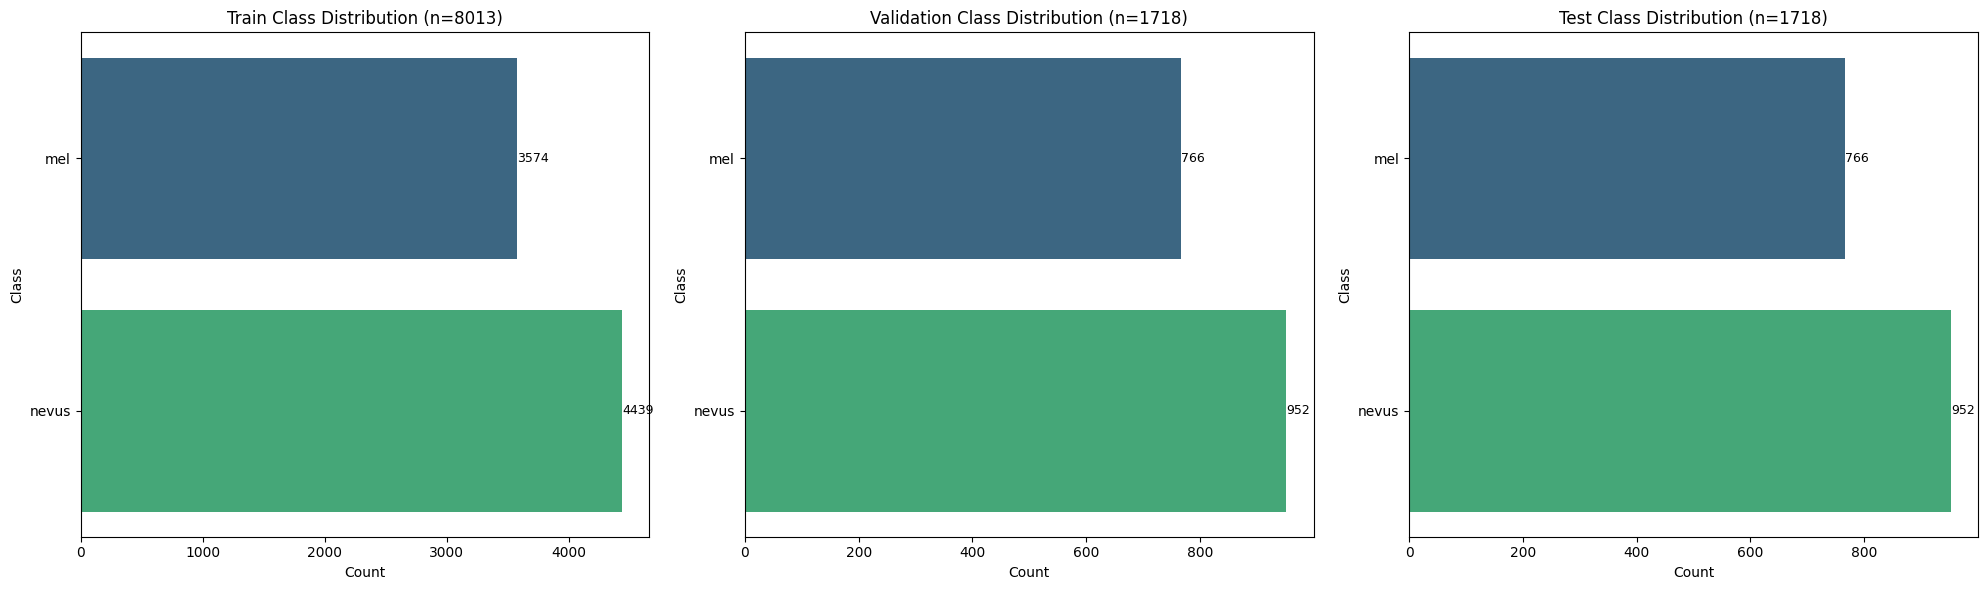

In [11]:
# ----------------------------- Class distribution visualization -----------------------------
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
splits = [("Train", train_df), ("Validation", val_df), ("Test", test_df)]

for ax, (split_name, df) in zip(axes, splits):
    counts = df["label"].value_counts().reindex(CLASS_NAMES).fillna(0)
    sns.barplot(x=counts.values, y=counts.index, ax=ax, palette="viridis")
    ax.set_title(f"{split_name} Class Distribution (n={len(df)})")
    ax.set_xlabel("Count")
    ax.set_ylabel("Class")
    for i, v in enumerate(counts.values):
        ax.text(v + 0.5, i, str(int(v)), va="center", fontsize=9)

plt.tight_layout()
plt.savefig(RESULTS_DIR / "class_distribution.png", dpi=150, bbox_inches="tight")
plt.show()


In [12]:
# ----------------------------- Class imbalance -> class weights -----------------------------
# We compute inverse-frequency class weights from the TRAIN split only.
# These are used in CrossEntropyLoss in Part 3 to counter class imbalance.
class_counts = train_df["label_idx"].value_counts().sort_index()
class_weights = (1.0 / class_counts) * (class_counts.sum() / NUM_CLASSES)
class_weights = torch.tensor(class_weights.values, dtype=torch.float32)

print("Class weights (inverse-frequency, normalized):")
for c, w in zip(CLASS_NAMES, class_weights):
    print(f"  {c}: {w:.3f}")


Class weights (inverse-frequency, normalized):
  mel: 1.121
  nevus: 0.903


### Transforms / Augmentation

Training images get random horizontal/vertical flips, rotation, random-resized-crop, and color
jitter. Validation and Test images only get deterministic resize + normalize (no augmentation),
since they must reflect real-world inference conditions.


In [13]:
# ----------------------------- Transform pipelines -----------------------------
IMG_SIZE = CONFIG["img_size"]

# ImageNet normalization stats (required since both backbones are ImageNet-pretrained)
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

# Overfitting fix: RandomErasing randomly blanks out a rectangular patch of the image AFTER
# normalization. This forces the model to rely on multiple regions of the lesion rather than
# memorizing one specific salient patch -- a standard, lightweight regularizer that pairs well
# with the geometric/color augmentations below.
train_transform = transforms.Compose([
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.3),
    transforms.RandomRotation(degrees=20),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.05),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    transforms.RandomErasing(p=0.25, scale=(0.02, 0.15), ratio=(0.3, 3.3)),
])

eval_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

# A transform-free version is also kept for Grad-CAM/visualization (needs raw 0-1 image for overlay)
visual_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
])

print("Transform pipelines ready.")


Transform pipelines ready.


In [14]:
# ----------------------------- Custom Dataset -----------------------------
# NOTE ON A COMMON CRASH: cv2.imread()/cv2.cvtColor() inside a DataLoader worker process
# (num_workers > 0) is a well-known source of slow memory leaks on Linux, because OpenCV's
# internal thread pool does not interact safely with fork()-based multiprocessing. Symptoms
# look exactly like: training runs fine for 1-2 epochs, then a worker's RSS creeps up until
# the OS OOM-killer kills it (RuntimeError: "DataLoader worker (pid ...) is killed by signal").
# We therefore load images with PIL directly (no OpenCV in the per-sample hot path) -- PIL's
# decoder is fork-safe and does not leak across worker processes.

from PIL import Image as PILImage

class SkinLesionDataset(Dataset):
    '''Loads an image from disk given a dataframe of [filepath, label_idx] and applies a transform.'''

    def __init__(self, df: pd.DataFrame, transform=None):
        self.filepaths = df["filepath"].values
        self.labels = df["label_idx"].values
        self.transform = transform

    def __len__(self):
        return len(self.filepaths)

    def __getitem__(self, idx):
        img_path = self.filepaths[idx]
        label = int(self.labels[idx])

        # PIL handles the read + RGB conversion directly -- avoids OpenCV's per-worker
        # memory growth under multiprocessing DataLoaders.
        image = PILImage.open(img_path).convert("RGB")

        if self.transform is not None:
            image = self.transform(image)

        return image, label


In [15]:
# ----------------------------- Datasets & DataLoaders -----------------------------
train_dataset = SkinLesionDataset(train_df, transform=train_transform)
val_dataset = SkinLesionDataset(val_df, transform=eval_transform)
test_dataset = SkinLesionDataset(test_df, transform=eval_transform)

# persistent_workers=True avoids respawning fresh worker processes every epoch (cheaper, and
# sidesteps some repeated-fork memory fragmentation). prefetch_factor is kept modest (2) so
# workers don't queue up many decoded images in RAM at once.
_loader_kwargs = dict(
    num_workers=CONFIG["num_workers"],
    pin_memory=True,
    persistent_workers=CONFIG["num_workers"] > 0,
    prefetch_factor=2 if CONFIG["num_workers"] > 0 else None,
)

train_loader = DataLoader(
    train_dataset, batch_size=CONFIG["batch_size"], shuffle=True,
    drop_last=True, **_loader_kwargs,
)
val_loader = DataLoader(
    val_dataset, batch_size=CONFIG["batch_size"], shuffle=False,
    **_loader_kwargs,
)
test_loader = DataLoader(
    test_dataset, batch_size=CONFIG["batch_size"], shuffle=False,
    **_loader_kwargs,
)

print(f"Train batches:      {len(train_loader)}")
print(f"Validation batches: {len(val_loader)}")
print(f"Test batches:       {len(test_loader)}")


Train batches:      250
Validation batches: 54
Test batches:       54


### Sample Images

Display a grid of raw sample images (one per class where available) before any augmentation,
followed by a grid of augmented training images to sanity-check the pipeline.


In [ ]:
# ----------------------------- Display raw sample images (multiple per class) -----------------------------
# For a small number of classes, showing several examples per class is more informative
# than a single image per class.
samples_per_class = 4

fig, axes = plt.subplots(NUM_CLASSES, samples_per_class, figsize=(4 * samples_per_class, 4 * NUM_CLASSES))
if NUM_CLASSES == 1:
    axes = axes.reshape(1, -1)

for row_idx, class_name in enumerate(CLASS_NAMES):
    class_rows = train_df[train_df["label"] == class_name].sample(
        n=min(samples_per_class, (train_df["label"] == class_name).sum()), random_state=SEED
    )
    for col_idx, (_, sample_row) in enumerate(class_rows.iterrows()):
        img = cv2.imread(sample_row["filepath"])
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        ax = axes[row_idx, col_idx]
        ax.imshow(img)
        ax.set_title(class_name if col_idx == 0 else "", fontsize=11, loc="left")
        ax.axis("off")
    # Hide any unused columns if a class has fewer than samples_per_class images
    for col_idx in range(len(class_rows), samples_per_class):
        axes[row_idx, col_idx].axis("off")

plt.suptitle("Sample Images per Class (Raw, Pre-Augmentation)", fontsize=14)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "sample_images_raw.png", dpi=150, bbox_inches="tight")
plt.show()


In [ ]:
# ----------------------------- Display augmented training batch -----------------------------
def denormalize(tensor_img):
    '''Reverse ImageNet normalization for display purposes.'''
    mean = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
    std = torch.tensor(IMAGENET_STD).view(3, 1, 1)
    img = tensor_img.cpu() * std + mean
    img = img.clamp(0, 1).permute(1, 2, 0).numpy()
    return img

sample_imgs, sample_labels = next(iter(train_loader))

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()
for i in range(min(8, len(sample_imgs))):
    axes[i].imshow(denormalize(sample_imgs[i]))
    axes[i].set_title(CLASS_NAMES[sample_labels[i].item()], fontsize=10)
    axes[i].axis("off")

plt.suptitle("Sample Augmented Training Batch", fontsize=14)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "sample_images_augmented.png", dpi=150, bbox_inches="tight")
plt.show()


## Part 2 — Hybrid DenseNet121 + ViT-B/16 Architecture with Cross-Attention Fusion

### Why this combination?

CNNs (like DenseNet121) and Vision Transformers (ViT) have **fundamentally different inductive
biases** — they "see" images in complementary ways:

| | DenseNet121 (CNN) | ViT-B/16 (Transformer) |
|---|---|---|
| **Sees** | Local textures, edges, fine-grained detail | Global structure, long-range relationships |
| **Mechanism** | Sliding convolution kernels | Self-attention across 16×16 image patches |
| **Strength** | Great at finding the lesion border, color patterns | Great at understanding overall shape & context |
| **Weakness** | Limited global context | Needs more data; misses fine local detail |

**Simple concatenation** (previous notebook) just stacks both feature vectors blindly.
**Cross-Attention Fusion** lets the two branches *talk to each other*: the ViT's global
representation attends to the CNN's spatial feature map, weighting which local regions matter
most for the final prediction. This is how the human brain combines peripheral and foveal vision.

### Architecture diagram

```
Input Image (3 × 224 × 224)
         │
    ┌────┴────────────────────────────────┐
    │                                     │
    ▼                                     ▼
DenseNet121                          ViT-B/16
(pretrained ImageNet)                (pretrained ImageNet-21k)
    │                                     │
    ▼                                     ▼
Feature Map                          CLS Token
(B × 1024 × 7 × 7)                  (B × 768)
    │                                     │
    │         Cross-Attention             │
    │    ┌────────────────────────┐       │
    └───►│  Query: ViT CLS token  │◄──────┘
         │  Key/Value: CNN spatial │
         │  feature map (49 patches│
         │  of 1024-d each)        │
         └──────────┬─────────────┘
                    │
              Attended output
              (B × 768)  ← ViT-shaped, but enriched with CNN spatial info
                    │
              Concatenate with CLS token
              (B × 1536)
                    │
              Fusion Head
         Linear(1536→512) → BN → Dropout(0.5)
                → ReLU → Dropout(0.3) → Linear(512→2)
                    │
              Prediction (mel / nevus)
```

### Partial freezing strategy (anti-overfitting)

- **DenseNet121:** freeze blocks 1-3, keep `denseblock4` + `norm5` trainable
- **ViT-B/16:** freeze encoder blocks 0-8, keep last 3 blocks (9, 10, 11) trainable
- **Cross-Attention + Fusion head:** always fully trainable (newly initialized)

This keeps ~30-35% of parameters trainable — enough capacity to adapt to skin lesion features
without memorizing the training set.


In [16]:
# ----------------------------- Cross-Attention Module -----------------------------
# This is the key innovation in this architecture. Let's understand what it does:
#
# DenseNet gives us a spatial feature map: (B, 1024, 7, 7)
#   → 7×7 = 49 spatial locations, each with a 1024-d feature vector
#   → Think of these as 49 "local experts", each describing one region of the lesion
#
# ViT gives us a CLS token: (B, 768)
#   → One global vector summarizing the whole image
#   → Think of this as the "global consultant"
#
# Cross-Attention asks: "Given the global context (CLS), which of the 49 local regions
# are most important?" It computes attention weights over the 49 CNN locations, then
# returns a weighted summary of them — shaped like the ViT's own representation space.

class CrossAttentionFusion(nn.Module):
    '''
    Multi-head Cross-Attention where:
      - Query  comes from ViT CLS token      (B, 1, 768)
      - Key    comes from DenseNet spatial map (B, 49, 1024) projected to 768
      - Value  comes from DenseNet spatial map (B, 49, 1024) projected to 768

    Output: attended vector (B, 768) — ViT-shaped summary enriched by CNN spatial info.
    '''

    def __init__(self, cnn_dim: int = 1024, vit_dim: int = 768,
                 num_heads: int = 8, dropout: float = 0.1):
        super().__init__()

        self.vit_dim = vit_dim
        self.num_heads = num_heads

        # Project CNN features from 1024-d to 768-d (ViT's space)
        # This is needed because Key/Value must live in the same space as Query
        self.cnn_proj = nn.Linear(cnn_dim, vit_dim)

        # Multi-head attention: Query=ViT, Key=CNN, Value=CNN
        # batch_first=True means input shape is (B, seq_len, dim) not (seq_len, B, dim)
        self.cross_attn = nn.MultiheadAttention(
            embed_dim=vit_dim,
            num_heads=num_heads,
            dropout=dropout,
            batch_first=True,
        )

        # Layer normalization: stabilizes training in Transformer architectures
        self.norm_query = nn.LayerNorm(vit_dim)
        self.norm_cnn   = nn.LayerNorm(vit_dim)
        self.norm_out   = nn.LayerNorm(vit_dim)

        # Feed-forward sub-layer (standard Transformer block design)
        self.ffn = nn.Sequential(
            nn.Linear(vit_dim, vit_dim * 2),
            nn.GELU(),           # GELU activation (standard in Transformers, smoother than ReLU)
            nn.Dropout(dropout),
            nn.Linear(vit_dim * 2, vit_dim),
            nn.Dropout(dropout),
        )
        self.norm_ffn = nn.LayerNorm(vit_dim)

    def forward(self, cnn_spatial: torch.Tensor, vit_cls: torch.Tensor):
        '''
        Args:
            cnn_spatial: DenseNet spatial feature map, shape (B, 1024, 7, 7)
            vit_cls:     ViT CLS token,                 shape (B, 768)
        Returns:
            attended:    enriched CLS representation,   shape (B, 768)
        '''
        B = cnn_spatial.size(0)

        # Step 1: Reshape CNN map from (B, 1024, 7, 7) → (B, 49, 1024)
        # 49 = 7*7 spatial locations, each with 1024 features
        cnn_seq = cnn_spatial.flatten(2).transpose(1, 2)   # (B, 49, 1024)

        # Step 2: Project CNN features to ViT's dimension space → (B, 49, 768)
        cnn_seq = self.cnn_proj(cnn_seq)                    # (B, 49, 768)

        # Step 3: Layer normalize both inputs before attention (Pre-LN design, more stable)
        query = self.norm_query(vit_cls.unsqueeze(1))       # (B, 1, 768)  ← add seq dim
        key_val = self.norm_cnn(cnn_seq)                    # (B, 49, 768)

        # Step 4: Cross-Attention
        # Query=ViT asks "what local CNN regions are relevant to my global understanding?"
        # Key/Value=CNN answers with the 49 spatial feature vectors
        attended, _ = self.cross_attn(
            query=query,       # (B, 1, 768)
            key=key_val,       # (B, 49, 768)
            value=key_val,     # (B, 49, 768)
        )
        attended = attended.squeeze(1)                      # (B, 768) ← remove seq dim

        # Step 5: Residual connection (standard Transformer design)
        # "Keep the original CLS info + add the attended CNN info"
        attended = self.norm_out(attended + vit_cls)        # (B, 768)

        # Step 6: Feed-forward with another residual
        attended = self.norm_ffn(attended + self.ffn(attended))  # (B, 768)

        return attended


In [17]:
# ----------------------------- Hybrid DenseNet121 + ViT-B/16 Model -----------------------------
class HybridDenseViT(nn.Module):
    '''
    Hybrid architecture combining:
      - DenseNet121  (CNN branch):  captures local texture / fine-grained lesion details
      - ViT-B/16     (ViT branch):  captures global structure via patch-level self-attention
      - CrossAttentionFusion:       ViT CLS token attends to DenseNet spatial features

    Partial backbone freezing is applied via freeze_backbone_layers() to prevent overfitting.
    '''

    def __init__(self, num_classes: int = 2, dropout: float = 0.5,
                 cross_attn_heads: int = 8, cross_attn_dropout: float = 0.1,
                 pretrained: bool = True):
        super().__init__()

        # ----------------------------------------------------------------
        # Branch 1: DenseNet121
        # ----------------------------------------------------------------
        densenet_weights = DenseNet121_Weights.IMAGENET1K_V1 if pretrained else None
        densenet = models.densenet121(weights=densenet_weights)

        # Keep only the feature extractor (remove the classifier head)
        self.densenet_features = densenet.features     # outputs (B, 1024, 7, 7)
        self.densenet_out_dim = densenet.classifier.in_features  # 1024

        # ----------------------------------------------------------------
        # Branch 2: ViT-B/16
        # ----------------------------------------------------------------
        # torchvision's ViT-B/16 pretrained on ImageNet-21k then fine-tuned on ImageNet-1k
        from torchvision.models import vit_b_16, ViT_B_16_Weights
        vit_weights = ViT_B_16_Weights.IMAGENET1K_V1 if pretrained else None
        vit = vit_b_16(weights=vit_weights)

        # ViT-B/16 internals we need:
        #   conv_proj   : patches the image into 196 tokens (14×14 patches of 16×16 pixels)
        #                 Note: ViT with img_size=224 produces 14×14 = 196 patch tokens
        #                 + 1 CLS token = 197 total tokens
        #   class_token : the learnable CLS token prepended to patch sequence
        #   encoder     : 12 Transformer encoder blocks
        # We discard ViT's own classification head (vit.heads)
        self.vit_conv_proj    = vit.conv_proj          # patch embedding layer
        self.vit_class_token  = vit.class_token        # learnable CLS token (1, 1, 768)
        self.vit_encoder      = vit.encoder            # 12 encoder blocks + pos embedding
        self.vit_out_dim      = vit.hidden_dim         # 768

        # ----------------------------------------------------------------
        # Cross-Attention Fusion
        # ----------------------------------------------------------------
        self.cross_attention = CrossAttentionFusion(
            cnn_dim=self.densenet_out_dim,   # 1024
            vit_dim=self.vit_out_dim,        # 768
            num_heads=cross_attn_heads,
            dropout=cross_attn_dropout,
        )

        # After cross-attention: attended (768) + original CLS (768) → concat → 1536
        fused_dim = self.vit_out_dim * 2    # 768 + 768 = 1536

        # ----------------------------------------------------------------
        # Fusion Head
        # ----------------------------------------------------------------
        self.fusion = nn.Sequential(
            nn.Linear(fused_dim, 512),
            nn.BatchNorm1d(512),
            nn.Dropout(dropout),
            nn.ReLU(inplace=True),
        )
        self.pre_classifier_dropout = nn.Dropout(dropout * 0.6)
        self.classifier = nn.Linear(512, num_classes)

    # ----------------------------------------------------------------
    # ViT forward helper
    # ----------------------------------------------------------------
    def _forward_vit(self, x: torch.Tensor):
        '''
        Run ViT forward pass manually so we can extract the CLS token.
        torchvision's ViT returns only the class prediction by default.

        Returns:
            cls_token: (B, 768) — the CLS token after all 12 encoder blocks
        '''
        B = x.size(0)

        # 1. Patch embedding: (B, 3, 224, 224) → (B, 196, 768)
        #    conv_proj applies a 16×16 conv with 768 filters → 14×14 feature map
        #    then reshapes to a sequence of 196 patch tokens
        x = self.vit_conv_proj(x)                         # (B, 768, 14, 14)
        x = x.flatten(2).transpose(1, 2)                  # (B, 196, 768)

        # 2. Prepend learnable CLS token: → (B, 197, 768)
        cls_tokens = self.vit_class_token.expand(B, -1, -1)  # (B, 1, 768)
        x = torch.cat([cls_tokens, x], dim=1)             # (B, 197, 768)

        # 3. Transformer encoder (adds positional embedding internally, then 12 blocks)
        x = self.vit_encoder(x)                           # (B, 197, 768)

        # 4. Extract CLS token (position 0) — this is ViT's global representation
        cls_token = x[:, 0, :]                            # (B, 768)
        return cls_token

    # ----------------------------------------------------------------
    # Feature extraction (used for t-SNE / UMAP in Part 7)
    # ----------------------------------------------------------------
    def extract_features(self, x: torch.Tensor):
        '''Returns the fused feature vector before the classification head.'''
        # CNN branch: spatial feature map
        cnn_spatial = self.densenet_features(x)            # (B, 1024, 7, 7)

        # ViT branch: CLS token
        vit_cls = self._forward_vit(x)                     # (B, 768)

        # Cross-Attention: ViT attends to CNN spatial locations
        attended = self.cross_attention(cnn_spatial, vit_cls)  # (B, 768)

        # Concatenate: original CLS + attended CLS → richer representation
        fused = torch.cat([vit_cls, attended], dim=1)      # (B, 1536)
        return fused

    # ----------------------------------------------------------------
    # Forward pass
    # ----------------------------------------------------------------
    def forward(self, x: torch.Tensor):
        fused = self.extract_features(x)
        hidden = self.fusion(fused)
        hidden = self.pre_classifier_dropout(hidden)
        logits = self.classifier(hidden)
        return logits

    # ----------------------------------------------------------------
    # Backbone freezing (anti-overfitting)
    # ----------------------------------------------------------------
    def freeze_backbone_layers(self, densenet_unfreeze_from: str = 'denseblock4',
                                vit_unfreeze_last_n_blocks: int = 3):
        '''
        Freeze early backbone layers to prevent overfitting.

        DenseNet: freeze all, then re-enable from densenet_unfreeze_from onward.
        ViT:      freeze patch embedding + early encoder blocks,
                  keep last vit_unfreeze_last_n_blocks blocks trainable.
        Cross-Attention + Fusion head: always trainable (newly initialized).
        '''
        # ---- DenseNet freezing ----
        for param in self.densenet_features.parameters():
            param.requires_grad = False

        unfreezing = False
        for name, module in self.densenet_features.named_children():
            if densenet_unfreeze_from in name:
                unfreezing = True
            if unfreezing:
                for param in module.parameters():
                    param.requires_grad = True

        # ---- ViT freezing ----
        # Freeze patch embedding and CLS token
        for param in self.vit_conv_proj.parameters():
            param.requires_grad = False
        self.vit_class_token.requires_grad = False

        # ViT encoder has: pos_embedding + layers (12 encoder blocks)
        # Freeze positional embedding
        self.vit_encoder.pos_embedding.requires_grad = False

        # Freeze encoder blocks, keep only the last N trainable
        total_blocks = len(self.vit_encoder.layers)        # 12 for ViT-B/16
        freeze_up_to = total_blocks - vit_unfreeze_last_n_blocks  # e.g. freeze 0..8

        for i, block in enumerate(self.vit_encoder.layers):
            requires_grad = i >= freeze_up_to
            for param in block.parameters():
                param.requires_grad = requires_grad

        # ViT encoder's final LayerNorm — always trainable
        for param in self.vit_encoder.ln.parameters():
            param.requires_grad = True

        # ---- Cross-Attention + Fusion always trainable ----
        for param in self.cross_attention.parameters():
            param.requires_grad = True
        for param in self.fusion.parameters():
            param.requires_grad = True
        for param in self.classifier.parameters():
            param.requires_grad = True

    def trainable_parameter_summary(self):
        total     = sum(p.numel() for p in self.parameters())
        trainable = sum(p.numel() for p in self.parameters() if p.requires_grad)
        return trainable, total, trainable / total if total > 0 else 0.0


In [18]:
# ----------------------------- Instantiate model -----------------------------
model = HybridDenseViT(
    num_classes=NUM_CLASSES,
    dropout=CONFIG['dropout'],
    cross_attn_heads=CONFIG['cross_attn_heads'],
    cross_attn_dropout=CONFIG['cross_attn_dropout'],
    pretrained=True,
).to(DEVICE)

# Apply partial backbone freezing
model.freeze_backbone_layers(
    densenet_unfreeze_from=CONFIG['densenet_unfreeze_from'],
    vit_unfreeze_last_n_blocks=CONFIG['vit_unfreeze_last_n_blocks'],
)

trainable, total, frac = model.trainable_parameter_summary()
print(f'Total parameters:      {total:,}')
print(f'Trainable parameters:  {trainable:,}  ({frac*100:.1f}% of total)')
print(f'Frozen parameters:     {total - trainable:,}  ({(1-frac)*100:.1f}% of total)')


Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /root/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth


100%|██████████| 30.8M/30.8M [00:00<00:00, 181MB/s]


Downloading: "https://download.pytorch.org/models/vit_b_16-c867db91.pth" to /root/.cache/torch/hub/checkpoints/vit_b_16-c867db91.pth


100%|██████████| 330M/330M [00:01<00:00, 234MB/s] 


Total parameters:      99,058,818
Trainable parameters:  29,731,586  (30.0% of total)
Frozen parameters:     69,327,232  (70.0% of total)


In [19]:
# ----------------------------- Per-module trainability breakdown -----------------------------
print('Trainable status by module:\n')
modules = {
    'densenet_features': model.densenet_features,
    'vit_conv_proj':     model.vit_conv_proj,
    'vit_encoder':       model.vit_encoder,
    'cross_attention':   model.cross_attention,
    'fusion':            model.fusion,
    'classifier':        model.classifier,
}
for name, mod in modules.items():
    n_train = sum(p.numel() for p in mod.parameters() if p.requires_grad)
    n_total = sum(p.numel() for p in mod.parameters())
    pct = n_train / n_total * 100 if n_total > 0 else 0
    status = 'TRAINABLE' if pct == 100 else ('FROZEN' if pct == 0 else f'PARTIAL {pct:.0f}%')
    print(f'  {name:20s}: {status:20s} ({n_train:>9,} / {n_total:>9,})')


Trainable status by module:

  densenet_features   : PARTIAL 31%          (2,160,128 / 6,953,856)
  vit_conv_proj       : FROZEN               (        0 /   590,592)
  vit_encoder         : PARTIAL 25%          (21,265,152 / 85,207,296)
  cross_attention     : TRAINABLE            (5,517,312 / 5,517,312)
  fusion              : TRAINABLE            (  787,968 /   787,968)
  classifier          : TRAINABLE            (    1,026 /     1,026)


In [20]:
# ----------------------------- Sanity check: forward pass shapes -----------------------------
model.eval()
with torch.no_grad():
    dummy = torch.randn(2, 3, 224, 224).to(DEVICE)
    feats  = model.extract_features(dummy)
    logits = model(dummy)

print(f'Input shape:         {tuple(dummy.shape)}')
print(f'Fused feature shape: {tuple(feats.shape)}   (expected: [2, 1536])')
print(f'Output logits shape: {tuple(logits.shape)}  (expected: [2, {NUM_CLASSES}])')
model.train()


Input shape:         (2, 3, 224, 224)
Fused feature shape: (2, 1536)   (expected: [2, 1536])
Output logits shape: (2, 2)  (expected: [2, 2])


HybridDenseViT(
  (densenet_features): Sequential(
    (conv0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (norm0): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu0): ReLU(inplace=True)
    (pool0): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (denseblock1): _DenseBlock(
      (denselayer1): _DenseLayer(
        (norm1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu1): ReLU(inplace=True)
        (conv1): Conv2d(64, 128, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (norm2): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu2): ReLU(inplace=True)
        (conv2): Conv2d(128, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      )
      (denselayer2): _DenseLayer(
        (norm1): BatchNorm2d(96, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True

## Part 3 — Training

Training setup:

- **Loss:** `CrossEntropyLoss` weighted by inverse-frequency class weights (Part 1), with
  **label smoothing** (`CONFIG["label_smoothing"]`) -- this softens the hard 0/1 targets so the
  model is penalized for being *overconfident*, which directly counters overfitting.
- **Optimizer:** `AdamW`, applied **only to trainable parameters** (frozen backbone layers from
  Part 2 are excluded, which also avoids wasting optimizer memory/state on them).
- **LR Scheduler:** `ReduceLROnPlateau` on validation loss.
- **Early Stopping:** stops training if validation loss doesn't improve for
  `CONFIG["early_stopping_patience"]` epochs, and restores the best checkpoint.
- **Mixed Precision:** enabled automatically when CUDA is available, via `torch.amp.autocast` +
  `GradScaler`.
- **Checkpointing:** the best model (lowest validation loss) is saved to `results/best_model.pt`.

**Overfitting countermeasures now in place (summary):** partial backbone freezing (Part 2),
higher dropout (0.5, plus a second dropout layer), label smoothing, increased weight decay
(5e-4), and stronger augmentation (Part 1, see `RandomErasing`). These work together rather
than relying on early stopping alone to paper over an over-capacity model.


In [21]:
# ----------------------------- Loss, optimizer, scheduler -----------------------------
criterion = nn.CrossEntropyLoss(
    weight=class_weights.to(DEVICE),
    label_smoothing=CONFIG["label_smoothing"],
)

# Only pass trainable parameters to the optimizer -- frozen backbone layers (Part 2) are
# excluded. This isn't strictly required for correctness (frozen params get no gradients
# either way), but it avoids allocating optimizer state (Adam's moment buffers) for tens of
# millions of parameters that will never be updated.
trainable_param_list = [p for p in model.parameters() if p.requires_grad]
optimizer = AdamW(trainable_param_list, lr=CONFIG["lr"], weight_decay=CONFIG["weight_decay"])

scheduler = ReduceLROnPlateau(
    optimizer, mode="min",
    factor=CONFIG["lr_scheduler_factor"],
    patience=CONFIG["lr_scheduler_patience"],
)

USE_AMP = torch.cuda.is_available()
scaler = GradScaler(enabled=USE_AMP)

print(f"Mixed precision (AMP) enabled: {USE_AMP}")
print(f"Label smoothing: {CONFIG['label_smoothing']}")
print(f"Optimizing {sum(p.numel() for p in trainable_param_list):,} trainable parameters "
      f"(out of {sum(p.numel() for p in model.parameters()):,} total).")


Mixed precision (AMP) enabled: True
Label smoothing: 0.1
Optimizing 29,731,586 trainable parameters (out of 99,058,818 total).


In [22]:
# ----------------------------- Early stopping helper -----------------------------
class EarlyStopping:
    '''Stops training when validation loss has not improved for `patience` consecutive epochs.'''

    def __init__(self, patience: int = 7, min_delta: float = 1e-4):
        self.patience = patience
        self.min_delta = min_delta
        self.best_loss = float("inf")
        self.counter = 0
        self.should_stop = False

    def step(self, val_loss: float) -> bool:
        '''Returns True if val_loss is a new best.'''
        if val_loss < self.best_loss - self.min_delta:
            self.best_loss = val_loss
            self.counter = 0
            return True
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.should_stop = True
            return False


early_stopper = EarlyStopping(patience=CONFIG["early_stopping_patience"])


In [23]:
# ----------------------------- Train / Validate one epoch -----------------------------

def run_one_epoch(model, loader, criterion, optimizer=None, scaler=None, train_mode=True):
    '''
    Runs a single epoch over `loader`. If `train_mode` is True, performs backprop;
    otherwise runs in inference mode (used for validation/test).
    Returns (avg_loss, accuracy).
    '''
    model.train() if train_mode else model.eval()

    running_loss = 0.0
    all_preds, all_labels = [], []

    context = torch.enable_grad() if train_mode else torch.no_grad()
    with context:
        progress = tqdm(loader, desc="Train" if train_mode else "Eval", leave=False)
        for images, labels in progress:
            images = images.to(DEVICE, non_blocking=True)
            labels = labels.to(DEVICE, non_blocking=True)

            if train_mode:
                optimizer.zero_grad(set_to_none=True)

            with autocast(device_type="cuda" if USE_AMP else "cpu", enabled=USE_AMP):
                outputs = model(images)
                loss = criterion(outputs, labels)

            if train_mode:
                scaler.scale(loss).backward()
                scaler.step(optimizer)
                scaler.update()

            running_loss += loss.item() * images.size(0)
            preds = outputs.argmax(dim=1)
            all_preds.extend(preds.detach().cpu().numpy())
            all_labels.extend(labels.detach().cpu().numpy())
            progress.set_postfix(loss=f"{loss.item():.4f}")

    avg_loss = running_loss / len(loader.dataset)
    accuracy = accuracy_score(all_labels, all_preds)
    return avg_loss, accuracy


In [24]:
# ----------------------------- Main training loop -----------------------------
history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
best_model_path = RESULTS_DIR / "best_model.pt"
best_val_loss = float("inf")

start_time = time.time()

for epoch in range(1, CONFIG["epochs"] + 1):
    epoch_start = time.time()

    train_loss, train_acc = run_one_epoch(
        model, train_loader, criterion, optimizer=optimizer, scaler=scaler, train_mode=True
    )
    val_loss, val_acc = run_one_epoch(
        model, val_loader, criterion, optimizer=None, scaler=None, train_mode=False
    )

    scheduler.step(val_loss)
    current_lr = optimizer.param_groups[0]["lr"]

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)

    epoch_time = time.time() - epoch_start
    print(
        f"Epoch {epoch:02d}/{CONFIG['epochs']} | "
        f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
        f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f} | "
        f"LR: {current_lr:.2e} | Time: {epoch_time:.1f}s"
    )

    # ----------------------------- Model checkpointing -----------------------------
    is_best = early_stopper.step(val_loss)
    if is_best:
        best_val_loss = val_loss
        # NOTE: cast metrics/labels to native Python types (float, list-of-str) before saving.
        # sklearn metrics (accuracy_score, etc.) return numpy scalars, and CLASS_NAMES comes
        # from label_encoder.classes_ (a numpy array of numpy.str_). Saving numpy objects
        # directly into the checkpoint makes it fail to load under PyTorch 2.6+'s default
        # weights_only=True unpickler, which blocks numpy global types by default.
        torch.save({
            "epoch": int(epoch),
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "val_loss": float(val_loss),
            "val_acc": float(val_acc),
            "config": CONFIG,
            "class_names": [str(c) for c in CLASS_NAMES],
        }, best_model_path)
        print(f"  -> New best model saved (val_loss={val_loss:.4f})")

    # ----------------------------- Early stopping check -----------------------------
    if early_stopper.should_stop:
        print(f"\nEarly stopping triggered at epoch {epoch} "
              f"(no improvement for {CONFIG['early_stopping_patience']} epochs).")
        break

total_train_time = time.time() - start_time
print(f"\nTotal training time: {total_train_time / 60:.1f} minutes")
print(f"Best validation loss: {best_val_loss:.4f}")


Train:   0%|          | 0/250 [00:00<?, ?it/s]

Eval:   0%|          | 0/54 [00:00<?, ?it/s]

Epoch 01/30 | Train Loss: 0.4110 | Train Acc: 0.8801 | Val Loss: 0.3888 | Val Acc: 0.8690 | LR: 1.00e-04 | Time: 518.9s
  -> New best model saved (val_loss=0.3888)


Train:   0%|          | 0/250 [00:00<?, ?it/s]

Eval:   0%|          | 0/54 [00:00<?, ?it/s]

...

Eval:   0%|          | 0/54 [00:00<?, ?it/s]

Epoch 13/30 | Train Loss: 0.2553 | Train Acc: 0.9752 | Val Loss: 0.3266 | Val Acc: 0.9331 | LR: 5.00e-05 | Time: 432.0s


Train:   0%|          | 0/250 [00:00<?, ?it/s]

Eval:   0%|          | 0/54 [00:00<?, ?it/s]

Epoch 14/30 | Train Loss: 0.2532 | Train Acc: 0.9756 | Val Loss: 0.3367 | Val Acc: 0.9342 | LR: 5.00e-05 | Time: 427.8s

Early stopping triggered at epoch 14 (no improvement for 7 epochs).

Total training time: 102.9 minutes
Best validation loss: 0.3073


In [25]:
# ----------------------------- Load best checkpoint for downstream evaluation -----------------------------
# weights_only=False is used here because this is a checkpoint we just saved ourselves
# earlier in this same notebook run (a fully trusted source) -- not a third-party file.
# PyTorch 2.6+ defaults torch.load to weights_only=True, which would otherwise block
# perfectly safe objects like plain dicts/lists/floats saved alongside the model weights.
checkpoint = torch.load(best_model_path, map_location=DEVICE, weights_only=False)
model.load_state_dict(checkpoint["model_state_dict"])
model.eval()

print(f"Loaded best model from epoch {checkpoint['epoch']} "
      f"(val_loss={checkpoint['val_loss']:.4f}, val_acc={checkpoint['val_acc']:.4f})")


Loaded best model from epoch 7 (val_loss=0.3073, val_acc=0.9377)


## Part 4 — Evaluation

We now run a single inference pass over the **held-out Test set** and collect:

- Raw logits / softmax probabilities (needed for ROC-AUC, PR-AUC)
- Hard predictions
- Ground-truth labels

From these we compute the **full metric suite**: Accuracy, Precision, Recall (Sensitivity),
Specificity, F1, Balanced Accuracy, ROC-AUC, PR-AUC, Matthews Correlation Coefficient,
Cohen's Kappa, and the full classification report.

Since this is a **binary clinical screening problem**, **melanoma (`mel`) is treated as the
positive class** for Precision/Recall/F1/ROC-AUC/PR-AUC — this matters because in melanoma
screening, missing a melanoma (a false negative) is far more clinically costly than a false
positive. Sensitivity (Recall on `mel`) and Specificity (on `nevus`) are reported individually
in addition to the standard metrics, since they are the two numbers a clinician would actually
care about.


In [26]:
# ----------------------------- Run inference over the Test set -----------------------------

@torch.no_grad()
def get_predictions(model, loader):
    '''Runs inference, returning (true_labels, predicted_labels, softmax_probabilities).'''
    model.eval()
    all_labels, all_preds, all_probs = [], [], []

    for images, labels in tqdm(loader, desc="Inference"):
        images = images.to(DEVICE, non_blocking=True)
        with autocast(device_type="cuda" if USE_AMP else "cpu", enabled=USE_AMP):
            outputs = model(images)
        probs = F.softmax(outputs.float(), dim=1)
        preds = probs.argmax(dim=1)

        all_labels.extend(labels.numpy())
        all_preds.extend(preds.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

    return np.array(all_labels), np.array(all_preds), np.array(all_probs)


y_true, y_pred, y_probs = get_predictions(model, test_loader)
print(f"Collected predictions for {len(y_true)} test images.")


Inference:   0%|          | 0/54 [00:00<?, ?it/s]

Collected predictions for 1718 test images.


In [27]:
# ----------------------------- Specificity helper (per-class + overall positive-class view) -----------------------------

def per_class_specificity_fn(y_true, y_pred, num_classes):
    '''
    Specificity = TN / (TN + FP), computed per class (one-vs-rest).
    sklearn has no built-in specificity metric, so we derive it from the confusion matrix.
    '''
    cm = confusion_matrix(y_true, y_pred, labels=range(num_classes))
    specificities = []
    for i in range(num_classes):
        tp = cm[i, i]
        fn = cm[i, :].sum() - tp
        fp = cm[:, i].sum() - tp
        tn = cm.sum() - tp - fn - fp
        spec = tn / (tn + fp) if (tn + fp) > 0 else 0.0
        specificities.append(spec)
    return specificities


# ----------------------------- Compute all metrics (mel = positive class) -----------------------------
pos_idx = POSITIVE_CLASS_IDX   # index of "mel" (melanoma)

metrics = {}
metrics["accuracy"] = accuracy_score(y_true, y_pred)

# Binary precision/recall/F1, with melanoma as the positive class.
metrics["precision_mel"] = precision_score(y_true, y_pred, pos_label=pos_idx, average="binary", zero_division=0)
metrics["recall_sensitivity_mel"] = recall_score(y_true, y_pred, pos_label=pos_idx, average="binary", zero_division=0)
metrics["f1_mel"] = f1_score(y_true, y_pred, pos_label=pos_idx, average="binary", zero_division=0)

# Specificity = recall of the NEGATIVE class (nevus) -- i.e. true-negative rate.
per_class_specificity = per_class_specificity_fn(y_true, y_pred, NUM_CLASSES)
metrics["specificity_nevus"] = per_class_specificity[1 - pos_idx]

metrics["balanced_accuracy"] = balanced_accuracy_score(y_true, y_pred)

# ROC-AUC / PR-AUC computed directly against the melanoma probability column.
mel_probs = y_probs[:, pos_idx]
y_true_binary = (y_true == pos_idx).astype(int)

try:
    metrics["roc_auc"] = roc_auc_score(y_true_binary, mel_probs)
except ValueError as e:
    metrics["roc_auc"] = float("nan")
    print(f"ROC-AUC could not be computed: {e}")

try:
    metrics["pr_auc"] = average_precision_score(y_true_binary, mel_probs)
except ValueError as e:
    metrics["pr_auc"] = float("nan")
    print(f"PR-AUC could not be computed: {e}")

metrics["mcc"] = matthews_corrcoef(y_true, y_pred)
metrics["cohen_kappa"] = cohen_kappa_score(y_true, y_pred)

print("=" * 55)
print("TEST SET METRICS (melanoma = positive class)")
print("=" * 55)
for k, v in metrics.items():
    print(f"{k:30s}: {v:.4f}")
print("=" * 55)


TEST SET METRICS (melanoma = positive class)
accuracy                      : 0.9307
precision_mel                 : 0.9218
recall_sensitivity_mel        : 0.9230
f1_mel                        : 0.9224
specificity_nevus             : 0.9230
balanced_accuracy             : 0.9300
roc_auc                       : 0.9796
pr_auc                        : 0.9796
mcc                           : 0.8598
cohen_kappa                   : 0.8598


In [ ]:
# ----------------------------- Per-class specificity breakdown -----------------------------
spec_df = pd.DataFrame({
    "class": CLASS_NAMES,
    "specificity": per_class_specificity,
})
print(spec_df.to_string(index=False))


In [ ]:
# ----------------------------- Full classification report -----------------------------
report_str = classification_report(
    y_true, y_pred, target_names=CLASS_NAMES, digits=4, zero_division=0
)
print(report_str)


In [ ]:
# ----------------------------- Save metrics + classification report to disk -----------------------------
with open(RESULTS_DIR / "metrics.txt", "w") as f:
    f.write("TEST SET METRICS\n")
    f.write("=" * 55 + "\n")
    for k, v in metrics.items():
        f.write(f"{k:30s}: {v:.4f}\n")
    f.write("\nPer-class specificity:\n")
    f.write(spec_df.to_string(index=False))
    f.write("\n")

with open(RESULTS_DIR / "classification_report.txt", "w") as f:
    f.write(report_str)

print(f"Saved: {RESULTS_DIR / 'metrics.txt'}")
print(f"Saved: {RESULTS_DIR / 'classification_report.txt'}")


## Part 5 — Visualization

We generate and save:

1. Confusion Matrix (raw counts)
2. Normalized Confusion Matrix (row-normalized, i.e. recall per class)
3. ROC Curve (binary, melanoma vs. nevus)
4. Precision-Recall Curve (binary, melanoma vs. nevus)
5. Training/Validation Loss curve
6. Training/Validation Accuracy curve

All figures are saved under `results/`.


In [ ]:
# ----------------------------- Confusion Matrix -----------------------------
cm = confusion_matrix(y_true, y_pred, labels=range(NUM_CLASSES))

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix (Test Set)")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()


In [ ]:
# ----------------------------- Normalized Confusion Matrix -----------------------------
cm_normalized = cm.astype(float) / cm.sum(axis=1, keepdims=True)
cm_normalized = np.nan_to_num(cm_normalized)

plt.figure(figsize=(10, 8))
sns.heatmap(cm_normalized, annot=True, fmt=".2f", cmap="Blues",
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, vmin=0, vmax=1)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Normalized Confusion Matrix (Test Set, Row-Normalized)")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "normalized_confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()


In [ ]:
# ----------------------------- ROC Curve (binary, melanoma = positive class) -----------------------------
fpr, tpr, _ = roc_curve(y_true_binary, mel_probs)
roc_auc_value = metrics["roc_auc"]

plt.figure(figsize=(8, 7))
plt.plot(fpr, tpr, color="crimson", lw=2.5, label=f"Hybrid model (AUC={roc_auc_value:.3f})")
plt.plot([0, 1], [0, 1], color="gray", lw=1, linestyle=":", label="Chance level")
plt.xlabel("False Positive Rate (1 − Specificity)")
plt.ylabel("True Positive Rate (Sensitivity)")
plt.title("ROC Curve — Melanoma Detection (Test Set)")
plt.legend(loc="lower right", fontsize=10)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "roc_curve.png", dpi=150, bbox_inches="tight")
plt.show()


In [ ]:
# ----------------------------- Precision-Recall Curve (binary, melanoma = positive class) -----------------------------
precision_vals, recall_vals, _ = precision_recall_curve(y_true_binary, mel_probs)
pr_auc_value = metrics["pr_auc"]

# Baseline = prevalence of melanoma in the test set (a no-skill classifier's expected precision)
baseline_precision = y_true_binary.mean()

plt.figure(figsize=(8, 7))
plt.plot(recall_vals, precision_vals, color="crimson", lw=2.5, label=f"Hybrid model (AP={pr_auc_value:.3f})")
plt.axhline(baseline_precision, color="gray", lw=1, linestyle=":",
            label=f"No-skill baseline (prevalence={baseline_precision:.3f})")
plt.xlabel("Recall (Sensitivity)")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve — Melanoma Detection (Test Set)")
plt.legend(loc="lower left", fontsize=10)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "precision_recall_curve.png", dpi=150, bbox_inches="tight")
plt.show()


In [ ]:
# ----------------------------- Training/Validation Loss Curve -----------------------------
epochs_range = range(1, len(history["train_loss"]) + 1)

plt.figure(figsize=(10, 6))
plt.plot(epochs_range, history["train_loss"], label="Train Loss", marker="o", markersize=3)
plt.plot(epochs_range, history["val_loss"], label="Validation Loss", marker="o", markersize=3)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training & Validation Loss Curve")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "loss_curve.png", dpi=150, bbox_inches="tight")
plt.show()


In [ ]:
# ----------------------------- Training/Validation Accuracy Curve -----------------------------
plt.figure(figsize=(10, 6))
plt.plot(epochs_range, history["train_acc"], label="Train Accuracy", marker="o", markersize=3)
plt.plot(epochs_range, history["val_acc"], label="Validation Accuracy", marker="o", markersize=3)
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training & Validation Accuracy Curve")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "accuracy_curve.png", dpi=150, bbox_inches="tight")
plt.show()


## Part 6 — Explainable
In this hybrid architecture we have two branches with very different internal structures:

- **DenseNet121 branch** — has traditional convolutional feature maps → we can apply
  **Grad-CAM** directly, targeting `densenet_features.norm5` (the last layer before GAP).
  This shows which *spatial regions* of the lesion the CNN branch focused on.

- **ViT branch** — has no spatial feature maps (only a sequence of patch tokens) → we use
  **Attention Map visualization**: we extract the attention weights from the last encoder block
  to show which image *patches* the Transformer attended to.

Both visualizations are generated side-by-side for each example so you can compare what
each branch "sees" in the same image.


In [ ]:
# ----------------------------- Grad-CAM wrapper for DenseNet branch -----------------------------
# pytorch-grad-cam needs a model whose forward() returns class logits.
# Our full model does that, so we can target sub-layers of it directly.

# Target layer: densenet_features.norm5 (last BN before GAP in DenseNet121)
densenet_target_layer = model.densenet_features.norm5

densenet_cam = GradCAM(model=model, target_layers=[densenet_target_layer])
print("DenseNet Grad-CAM ready (target: densenet_features.norm5)")


In [ ]:
# ----------------------------- ViT Attention Map extraction -----------------------------
# ViT-B/16 has 12 encoder blocks. Each block has a self-attention sub-layer.
# We hook the LAST encoder block's attention output to get attention weights.
# The CLS token's attention over the 196 patch tokens tells us which patches
# the model found most relevant globally.

_attention_map_storage = {}

def _vit_attention_hook(module, input, output):
    '''Hook to capture the raw attention weights from the last ViT encoder block.'''
    # In torchvision's ViT, the self-attention module returns (output, attn_weights)
    # when need_weights=True. We store the weights for later visualization.
    # output shape: (B, num_heads, seq_len, seq_len) for the attention weights
    _attention_map_storage['attn_weights'] = output

def get_vit_attention_map(model, input_tensor):
    '''
    Extract the attention map from the last ViT encoder block.
    Returns a (14, 14) heatmap of CLS token attention over the 196 patches.
    '''
    model.eval()
    last_block = model.vit_encoder.layers[-1]

    # The self-attention module is inside last_block.self_attention
    # We need to temporarily make it return attention weights
    original_forward = last_block.self_attention.forward

    attn_weights_captured = {}

    def patched_forward(query, key, value, **kwargs):
        out, weights = original_forward(query, key, value,
                                        need_weights=True, average_attn_weights=False)
        attn_weights_captured['weights'] = weights.detach()
        return out, weights

    last_block.self_attention.forward = patched_forward

    with torch.no_grad():
        _ = model(input_tensor)

    last_block.self_attention.forward = original_forward  # restore

    if 'weights' not in attn_weights_captured:
        return None

    # attn_weights: (B, num_heads, 197, 197)
    # Row 0 of the attention matrix = CLS token attending to all other tokens
    # Columns 1..196 = the 196 patch tokens
    attn = attn_weights_captured['weights'][0]       # (num_heads, 197, 197)
    cls_attn = attn[:, 0, 1:]                        # (num_heads, 196) — CLS → patches
    cls_attn = cls_attn.mean(dim=0)                  # (196,) — average over heads
    cls_attn = cls_attn.reshape(14, 14)               # (14, 14) — 14×14 patch grid
    cls_attn = (cls_attn - cls_attn.min()) / (cls_attn.max() - cls_attn.min() + 1e-8)
    cls_attn = cls_attn.cpu().numpy()
    return cls_attn


print("ViT attention map extractor ready.")


In [ ]:
# ----------------------------- Select correct + incorrect examples -----------------------------
from PIL import Image as PILImage

correct_mask   = (y_true == y_pred)
incorrect_mask = ~correct_mask

correct_indices   = np.where(correct_mask)[0]
incorrect_indices = np.where(incorrect_mask)[0]

n_examples = CONFIG['grad_cam_n_examples'] // 2
rng = np.random.RandomState(SEED)

selected_correct   = rng.choice(correct_indices,
                                 size=min(n_examples, len(correct_indices)),
                                 replace=False)
selected_incorrect = rng.choice(incorrect_indices,
                                 size=min(n_examples, len(incorrect_indices)),
                                 replace=False) \
    if len(incorrect_indices) > 0 else np.array([], dtype=int)

print(f"Selected {len(selected_correct)} correct and "
      f"{len(selected_incorrect)} incorrect examples.")


In [ ]:
# ----------------------------- Grad-CAM + Attention visualization function -----------------------------

def visualize_explainability(test_idx: int, save_prefix: str):
    '''
    For a single test image, generates:
      - DenseNet Grad-CAM overlay (which spatial region the CNN focused on)
      - ViT attention map overlay (which patches the Transformer focused on)
    Side by side with the original image and prediction info.
    '''
    row = test_df.iloc[test_idx]
    img_path  = row['filepath']
    true_idx  = int(row['label_idx'])

    # Load raw image (0-1 range) for overlay
    raw_pil  = PILImage.open(img_path).convert('RGB')
    raw_np   = np.array(visual_transform(raw_pil).permute(1, 2, 0))

    # Normalized input tensor for model
    input_tensor = eval_transform(raw_pil).unsqueeze(0).to(DEVICE)

    # Get prediction
    model.eval()
    with torch.no_grad():
        logits = model(input_tensor)
        probs  = F.softmax(logits.float(), dim=1)
        pred_idx    = int(probs.argmax(dim=1).item())
        confidence  = float(probs[0, pred_idx].item())

    pred_name = CLASS_NAMES[pred_idx]
    true_name = CLASS_NAMES[true_idx]
    is_correct = (pred_idx == true_idx)

    # ---- Grad-CAM (DenseNet branch) ----
    targets = [ClassifierOutputTarget(pred_idx)]
    grayscale_cam = densenet_cam(input_tensor=input_tensor, targets=targets)[0]
    densenet_overlay = show_cam_on_image(raw_np, grayscale_cam, use_rgb=True)

    # ---- ViT Attention Map ----
    attn_map = get_vit_attention_map(model, input_tensor)   # (14, 14)
    import cv2 as _cv2
    attn_resized = _cv2.resize(attn_map, (224, 224))
    attn_colored = plt.cm.jet(attn_resized)[..., :3]
    vit_overlay  = (0.5 * raw_np + 0.5 * attn_colored).clip(0, 1)

    # ---- Plot ----
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    axes[0].imshow(raw_np);           axes[0].set_title('Original Image');     axes[0].axis('off')
    axes[1].imshow(densenet_overlay); axes[1].set_title('DenseNet Grad-CAM\n(Local CNN regions)'); axes[1].axis('off')
    axes[2].imshow(vit_overlay);      axes[2].set_title('ViT Attention Map\n(Global patch attention)'); axes[2].axis('off')

    status = 'CORRECT' if is_correct else 'INCORRECT'
    color  = 'green'   if is_correct else 'red'
    fig.suptitle(f'[{status}]  True: {true_name}  |  Predicted: {pred_name}  '
                 f'(confidence={confidence:.3f})', color=color, fontsize=13)
    plt.tight_layout()

    save_path = RESULTS_DIR / 'gradcam' / f'{save_prefix}_idx{test_idx}_{status.lower()}.png'
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()


In [ ]:
# ----------------------------- Generate visualizations for correct examples -----------------------------
print("Correctly Classified Examples")
print("=" * 60)
for idx in selected_correct:
    visualize_explainability(int(idx), save_prefix='correct')


In [ ]:
# ----------------------------- Generate visualizations for incorrect examples -----------------------------
print("Incorrectly Classified Examples")
print("=" * 60)
if len(selected_incorrect) == 0:
    print("No incorrect predictions found -- skipping.")
else:
    for idx in selected_incorrect:
        visualize_explainability(int(idx), save_prefix='incorrect')


## Part 7 — Feature Visualization

We extract the **fused 3072-d feature vector** (DenseNet 1024-d + ResNet 2048-d, pre-fusion-head,
via `model.extract_features`) for test images, then project it down to 2D with both **t-SNE**
and **UMAP** to visually inspect how well-separated the learned class clusters are.

To keep this fast, we cap the number of samples used (`CONFIG["tsne_max_samples"]`), sampling
in a stratified way across classes.


In [ ]:
# ----------------------------- Extract deep features from the Hybrid model -----------------------------

@torch.no_grad()
def extract_all_features(model, loader):
    '''Runs the test loader through `model.extract_features` and collects (features, labels).'''
    model.eval()
    all_features, all_labels = [], []

    for images, labels in tqdm(loader, desc="Extracting features"):
        images = images.to(DEVICE, non_blocking=True)
        with autocast(device_type="cuda" if USE_AMP else "cpu", enabled=USE_AMP):
            feats = model.extract_features(images)
        all_features.append(feats.float().cpu().numpy())
        all_labels.append(labels.numpy())

    return np.concatenate(all_features, axis=0), np.concatenate(all_labels, axis=0)


test_features, test_feature_labels = extract_all_features(model, test_loader)
print(f"Extracted feature matrix shape: {test_features.shape}")


In [ ]:
# ----------------------------- Stratified subsampling for speed -----------------------------
max_samples = CONFIG["tsne_max_samples"]

if len(test_features) > max_samples:
    sample_df = pd.DataFrame({"idx": np.arange(len(test_feature_labels)), "label": test_feature_labels})
    sampled_idx = (
        sample_df.groupby("label", group_keys=False)
        .apply(lambda g: g.sample(
            n=max(1, int(max_samples * len(g) / len(sample_df))),
            random_state=SEED,
        ))["idx"].values
    )
    feat_subset = test_features[sampled_idx]
    label_subset = test_feature_labels[sampled_idx]
else:
    feat_subset = test_features
    label_subset = test_feature_labels

print(f"Using {len(feat_subset)} samples for t-SNE/UMAP visualization.")


In [ ]:
# ----------------------------- t-SNE -----------------------------
tsne = TSNE(
    n_components=2,
    perplexity=min(30, max(5, len(feat_subset) // 10)),
    random_state=SEED,
    init="pca",
    learning_rate="auto",
)
tsne_embedding = tsne.fit_transform(feat_subset)

plt.figure(figsize=(11, 9))
palette = sns.color_palette("tab10", n_colors=NUM_CLASSES)
for i, class_name in enumerate(CLASS_NAMES):
    mask = label_subset == i
    plt.scatter(
        tsne_embedding[mask, 0], tsne_embedding[mask, 1],
        s=18, alpha=0.7, color=palette[i], label=class_name,
    )
plt.title("t-SNE Projection of Fused Hybrid Features (Test Set)")
plt.xlabel("t-SNE Dim 1")
plt.ylabel("t-SNE Dim 2")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=9)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "tsne.png", dpi=150, bbox_inches="tight")
plt.show()


In [ ]:
# ----------------------------- UMAP -----------------------------
umap_reducer = umap.UMAP(
    n_components=2,
    random_state=SEED,
    n_neighbors=min(15, max(2, len(feat_subset) // 20)),
    min_dist=0.1,
)
umap_embedding = umap_reducer.fit_transform(feat_subset)

plt.figure(figsize=(11, 9))
for i, class_name in enumerate(CLASS_NAMES):
    mask = label_subset == i
    plt.scatter(
        umap_embedding[mask, 0], umap_embedding[mask, 1],
        s=18, alpha=0.7, color=palette[i], label=class_name,
    )
plt.title("UMAP Projection of Fused Hybrid Features (Test Set)")
plt.xlabel("UMAP Dim 1")
plt.ylabel("UMAP Dim 2")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=9)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "umap.png", dpi=150, bbox_inches="tight")
plt.show()


### t-SNE vs. UMAP — Comparison

Both methods project the same 3072-dimensional fused feature space into 2D, but with different
underlying assumptions:

- **t-SNE** optimizes local neighborhood preservation via a probabilistic similarity matching
  scheme; it tends to produce tight, well-separated clusters but distances *between* clusters
  are not meaningfully interpretable, and it can be sensitive to the `perplexity` hyperparameter.
- **UMAP** is based on manifold learning / topological data analysis; it tends to preserve more
  of the *global* structure (relative distances between clusters carry more meaning) and is
  generally faster on larger sample sizes.

Visually compare the two figures above: if the same classes that overlap in t-SNE also overlap
in UMAP, that is good evidence those classes are genuinely difficult to separate in feature
space (rather than an artifact of one specific projection method) — which should be cross-checked
against the confusion matrix in Part 5 and the error analysis in Part 8.


## Part 8 — Error Analysis

We build a results table over the full test set with: ground truth, predicted label, and
prediction confidence (softmax probability of the predicted class). From this table we examine:

1. **Correct predictions** (sample)
2. **Wrong predictions** (sample)
3. **Top confident errors** — wrong predictions the model was most confident about (most concerning)
4. **Least confident correct predictions** — correct predictions the model was *least* sure about
   (borderline cases, useful for understanding decision-boundary behavior)

Representative images from the wrong/correct buckets are saved under
`results/wrong_predictions/` and `results/correct_predictions/`.


In [ ]:
# ----------------------------- Build full results table -----------------------------
results_table = pd.DataFrame({
    "filepath": test_df["filepath"].values,
    "true_label": [CLASS_NAMES[i] for i in y_true],
    "predicted_label": [CLASS_NAMES[i] for i in y_pred],
    "confidence": y_probs[np.arange(len(y_pred)), y_pred],
    "is_correct": (y_true == y_pred),
})

print(f"Results table shape: {results_table.shape}")
results_table.head(10)


In [ ]:
# ----------------------------- Correct vs. wrong predictions summary -----------------------------
correct_df = results_table[results_table["is_correct"]].sort_values("confidence", ascending=False)
wrong_df = results_table[~results_table["is_correct"]].sort_values("confidence", ascending=False)

print(f"Total correct predictions: {len(correct_df)}  ({len(correct_df)/len(results_table)*100:.2f}%)")
print(f"Total wrong predictions:   {len(wrong_df)}  ({len(wrong_df)/len(results_table)*100:.2f}%)")


In [ ]:
# ----------------------------- Display sample correct predictions -----------------------------
print("Sample of Correct Predictions")
display(correct_df.head(10))


In [ ]:
# ----------------------------- Display sample wrong predictions -----------------------------
print("Sample of Wrong Predictions")
display(wrong_df.head(10))


In [ ]:
# ----------------------------- Top confident errors (most concerning) -----------------------------
top_confident_errors = wrong_df.head(8)
print("Top Confident Errors — model was wrong AND very confident about it")
display(top_confident_errors)


In [ ]:
# ----------------------------- Least confident correct predictions (borderline cases) -----------------------------
least_confident_correct = correct_df.sort_values("confidence", ascending=True).head(8)
print("Least Confident Correct Predictions — model got it right but was unsure")
display(least_confident_correct)


In [ ]:
# ----------------------------- Helper to plot + save a batch of example images -----------------------------

def plot_and_save_examples(df_subset: pd.DataFrame, title: str, save_dir: Path, filename_prefix: str):
    n = len(df_subset)
    if n == 0:
        print(f"No examples available for: {title}")
        return

    n_cols = min(4, n)
    n_rows = int(np.ceil(n / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 4 * n_rows))
    axes = np.array(axes).reshape(-1)

    for ax, (_, row) in zip(axes, df_subset.iterrows()):
        img = cv2.imread(row["filepath"])
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        ax.imshow(img)
        color = "green" if row["is_correct"] else "red"
        ax.set_title(
            f"True: {row['true_label']}\nPred: {row['predicted_label']} ({row['confidence']:.3f})",
            fontsize=9, color=color,
        )
        ax.axis("off")

    for ax in axes[n:]:
        ax.axis("off")

    fig.suptitle(title, fontsize=14)
    plt.tight_layout()

    save_path = save_dir / f"{filename_prefix}.png"
    plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved: {save_path}")


In [ ]:
# ----------------------------- Save correct prediction examples -----------------------------
plot_and_save_examples(
    correct_df.head(8), "Correct Predictions (Sample)",
    RESULTS_DIR / "correct_predictions", "correct_predictions_sample"
)


In [ ]:
# ----------------------------- Save wrong prediction examples -----------------------------
plot_and_save_examples(
    wrong_df.head(8), "Wrong Predictions (Sample)",
    RESULTS_DIR / "wrong_predictions", "wrong_predictions_sample"
)


In [ ]:
# ----------------------------- Save top confident errors -----------------------------
plot_and_save_examples(
    top_confident_errors, "Top Confident Errors",
    RESULTS_DIR / "wrong_predictions", "top_confident_errors"
)


In [ ]:
# ----------------------------- Save least confident correct predictions -----------------------------
plot_and_save_examples(
    least_confident_correct, "Least Confident Correct Predictions",
    RESULTS_DIR / "correct_predictions", "least_confident_correct"
)


In [ ]:
# ----------------------------- Export full results table -----------------------------
results_table.to_csv(RESULTS_DIR / "test_predictions_full.csv", index=False)
print(f"Saved full per-image prediction table to: {RESULTS_DIR / 'test_predictions_full.csv'}")


**Confidence Intervals**

In [28]:
# ============================================================
# Bootstrap 95% Confidence Intervals (Binary Classification)
# Positive class = Melanoma (label=1)
# ============================================================

import numpy as np
import pandas as pd

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    roc_auc_score,
    recall_score,
    confusion_matrix,
    f1_score,
    matthews_corrcoef
)

from sklearn.utils import resample
from tqdm.auto import tqdm


# ------------------------------------------------------------
# Bootstrap Function
# ------------------------------------------------------------

def bootstrap_metrics(
    y_true,
    y_pred,
    y_prob,
    n_bootstrap=2000,
    confidence=0.95,
    random_state=42,
):
    rng = np.random.RandomState(random_state)

    positive_idx = np.where(y_true == 1)[0]
    negative_idx = np.where(y_true == 0)[0]

    metrics = {
        "Accuracy": [],
        "Balanced Accuracy": [],
        "ROC-AUC": [],
        "Sensitivity": [],
        "Specificity": [],
        "F1": [],
        "MCC": []
    }

    n_pos = len(positive_idx)
    n_neg = len(negative_idx)

    for _ in tqdm(range(n_bootstrap), desc="Bootstrap"):

        # Stratified bootstrap
        pos_sample = resample(
            positive_idx,
            replace=True,
            n_samples=n_pos,
            random_state=rng.randint(0, 1_000_000),
        )

        neg_sample = resample(
            negative_idx,
            replace=True,
            n_samples=n_neg,
            random_state=rng.randint(0, 1_000_000),
        )

        idx = np.concatenate([pos_sample, neg_sample])

        yt = y_true[idx]
        yp = y_pred[idx]
        prob = y_prob[idx]

        # Accuracy
        metrics["Accuracy"].append(
            accuracy_score(yt, yp)
        )

        # Balanced Accuracy
        metrics["Balanced Accuracy"].append(
            balanced_accuracy_score(yt, yp)
        )

        # ROC-AUC
        try:
            metrics["ROC-AUC"].append(
                roc_auc_score(yt, prob)
            )
        except:
            continue

        # Sensitivity
        sens = recall_score(yt, yp, pos_label=1)
        metrics["Sensitivity"].append(sens)

        # Specificity
        tn, fp, fn, tp = confusion_matrix(
            yt, yp, labels=[0,1]
        ).ravel()

        spec = tn / (tn + fp)
        metrics["Specificity"].append(spec)

        # F1
        metrics["F1"].append(
            f1_score(yt, yp, pos_label=1)
        )

        # MCC
        metrics["MCC"].append(
            matthews_corrcoef(yt, yp)
        )

    alpha = (1 - confidence) / 2

    summary = []

    for metric, values in metrics.items():

        values = np.array(values)

        summary.append({
            "Metric": metric,
            "Mean": np.mean(values),
            "Lower 95% CI": np.percentile(values, alpha*100),
            "Upper 95% CI": np.percentile(values, (1-alpha)*100)
        })

    return pd.DataFrame(summary)


# ============================================================
# Run Bootstrap
# ============================================================

results_ci = bootstrap_metrics(
    y_true=y_true,
    y_pred=y_pred,
    y_prob=y_probs[:,1],      # Probability of Melanoma
    n_bootstrap=2000,
    confidence=0.95,
    random_state=42
)

results_ci

Bootstrap:   0%|          | 0/2000 [00:00<?, ?it/s]

,Metric,Mean,Lower 95% CI,Upper 95% CI
0,Accuracy,0.930465,0.918510,0.941793
1,Balanced Accuracy,0.929716,0.917413,0.941328
2,ROC-AUC,0.979463,0.973148,0.984916
3,Sensitivity,0.936632,0.920168,0.950630
4,Specificity,0.922800,0.903394,0.939948
5,F1,0.937217,0.926524,0.947589
6,MCC,0.859366,0.835047,0.882317


In [29]:
print("\nBootstrap 95% Confidence Intervals\n")

for _, row in results_ci.iterrows():
    print(
        f"{row['Metric']:<20}: "
        f"{row['Mean']:.4f} "
        f"(95% CI: {row['Lower 95% CI']:.4f} - {row['Upper 95% CI']:.4f})"
    )


Bootstrap 95% Confidence Intervals

Accuracy            : 0.9305 (95% CI: 0.9185 - 0.9418)
Balanced Accuracy   : 0.9297 (95% CI: 0.9174 - 0.9413)
ROC-AUC             : 0.9795 (95% CI: 0.9731 - 0.9849)
Sensitivity         : 0.9366 (95% CI: 0.9202 - 0.9506)
Specificity         : 0.9228 (95% CI: 0.9034 - 0.9399)
F1                  : 0.9372 (95% CI: 0.9265 - 0.9476)
MCC                 : 0.8594 (95% CI: 0.8350 - 0.8823)


McNemar Test

In [30]:
# ============================================================
# McNemar Test
# Hybrid DenseNet+ResNet vs Majority-Class Baseline
# ============================================================

import numpy as np
import pandas as pd
from statsmodels.stats.contingency_tables import mcnemar

# ------------------------------------------------------------
# Majority-Class Baseline Predictions
# ------------------------------------------------------------

majority_class = np.bincount(y_true).argmax()

y_pred_baseline = np.full_like(
    y_true,
    fill_value=majority_class
)

# ------------------------------------------------------------
# Correct / Incorrect masks
# ------------------------------------------------------------

model_correct = (y_pred == y_true)
baseline_correct = (y_pred_baseline == y_true)

# McNemar counts
n10 = np.sum(model_correct & (~baseline_correct))
n01 = np.sum((~model_correct) & baseline_correct)

n11 = np.sum(model_correct & baseline_correct)
n00 = np.sum((~model_correct) & (~baseline_correct))

table = [[n11, n10],
         [n01, n00]]

# ------------------------------------------------------------
# McNemar Test
# ------------------------------------------------------------

result = mcnemar(
    table,
    exact=False,
    correction=True
)

chi2 = result.statistic
p_value = result.pvalue

# ------------------------------------------------------------
# Interpretation
# ------------------------------------------------------------

if p_value < 0.05:
    if n10 > n01:
        interpretation = (
            "Model significantly outperforms the majority-class baseline"
        )
    else:
        interpretation = (
            "Baseline significantly outperforms the model"
        )
else:
    interpretation = (
        "No statistically significant difference"
    )

# ------------------------------------------------------------
# Results Table
# ------------------------------------------------------------

results_df = pd.DataFrame({
    "χ²": [chi2],
    "p-value": [p_value],
    "n01 (Model Wrong / Baseline Right)": [n01],
    "n10 (Model Right / Baseline Wrong)": [n10],
    "Interpretation": [interpretation]
})

display(results_df)

print("\nContingency Table")
print(pd.DataFrame(
    table,
    index=["Model Correct", "Model Wrong"],
    columns=["Baseline Correct", "Baseline Wrong"]
))

,χ²,p-value,n01 (Model Wrong / Baseline Right),n10 (Model Right / Baseline Wrong),Interpretation
0,544.088657,2.431980e-120,60,707,Model significantly outperforms the majority-c...



Contingency Table
               Baseline Correct  Baseline Wrong
Model Correct               892             707
Model Wrong                  60              59


**Decision Threshold Analysis> **

In [31]:
# ============================================================
# Decision Threshold Analysis
# Positive class = Melanoma (label=1)
# ============================================================

import numpy as np
import pandas as pd

from sklearn.metrics import (
    roc_curve,
    confusion_matrix,
    f1_score
)


def compute_metrics(y_true, probs, threshold):

    pred = (probs >= threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_true,
        pred,
        labels=[0,1]
    ).ravel()

    sensitivity = tp / (tp + fn)
    specificity = tn / (tn + fp)
    f1 = f1_score(y_true, pred)

    return sensitivity, specificity, f1


def decision_threshold_analysis(
        y_true,
        y_probs,
        default_threshold=0.50,
        screening_target=0.95):

    # probability of melanoma
    probs = y_probs[:,1]

    # --------------------------------------------------------
    # Default Threshold
    # --------------------------------------------------------

    sens_def, spec_def, f1_def = compute_metrics(
        y_true,
        probs,
        default_threshold
    )

    # --------------------------------------------------------
    # Youden Threshold
    # --------------------------------------------------------

    fpr, tpr, thresholds = roc_curve(y_true, probs)

    youden = tpr - fpr
    best_idx = np.argmax(youden)

    youden_threshold = thresholds[best_idx]

    sens_youden, spec_youden, f1_youden = compute_metrics(
        y_true,
        probs,
        youden_threshold
    )

    # --------------------------------------------------------
    # Screening Threshold
    # Highest Sensitivity
    # --------------------------------------------------------

    valid = np.where(tpr >= screening_target)[0]

    if len(valid):

        idx = valid[-1]       # highest specificity while maintaining sensitivity target

        screening_threshold = thresholds[idx]

        sens_scr, spec_scr, f1_scr = compute_metrics(
            y_true,
            probs,
            screening_threshold
        )

    else:

        screening_threshold = np.nan
        sens_scr = np.nan
        spec_scr = np.nan
        f1_scr = np.nan

    # --------------------------------------------------------

    results = pd.DataFrame({

        "Default Threshold":[default_threshold],
        "Sensitivity":[sens_def],
        "Specificity":[spec_def],
        "F1":[f1_def],

        "Youden Threshold":[youden_threshold],
        "Sensitivity ":[sens_youden],
        "Specificity ":[spec_youden],
        "F1 ":[f1_youden],

        "Screening Threshold":[screening_threshold],
        "Sensitivity  ":[sens_scr],
        "Specificity  ":[spec_scr]

    })

    return results


# ============================================================
# Run
# ============================================================

threshold_results = decision_threshold_analysis(
    y_true,
    y_probs,
    default_threshold=0.50,
    screening_target=0.95      # Change if desired
)

display(threshold_results.round(4))

,Default Threshold,Sensitivity,Specificity,F1,Youden Threshold,Sensitivity,Specificity,F1,Screening Threshold,Sensitivity,Specificity
0,0.5,0.937,0.923,0.9375,0.404,0.9548,0.9086,0.9415,0.0199,1.0,0.0


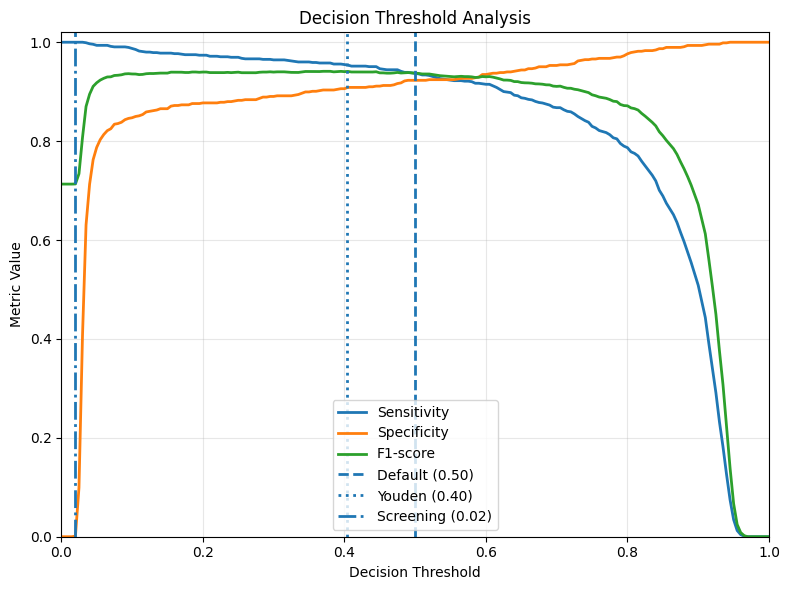

In [32]:
# ============================================================
# Decision Threshold Analysis Plot
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import (
    confusion_matrix,
    f1_score,
    roc_curve
)


def decision_threshold_plot(
        y_true,
        y_probs,
        default_threshold=0.50,
        screening_target=0.95):

    probs = y_probs[:,1]

    thresholds = np.linspace(0,1,201)

    sensitivity = []
    specificity = []
    f1_scores = []

    # --------------------------------------------------------
    # Metrics over all thresholds
    # --------------------------------------------------------

    for t in thresholds:

        pred = (probs >= t).astype(int)

        tn, fp, fn, tp = confusion_matrix(
            y_true,
            pred,
            labels=[0,1]
        ).ravel()

        sens = tp / (tp + fn)
        spec = tn / (tn + fp)

        f1 = f1_score(
            y_true,
            pred,
            zero_division=0
        )

        sensitivity.append(sens)
        specificity.append(spec)
        f1_scores.append(f1)

    # --------------------------------------------------------
    # Youden Threshold
    # --------------------------------------------------------

    fpr, tpr, roc_thresholds = roc_curve(y_true, probs)

    youden = tpr - fpr
    best_idx = np.argmax(youden)

    youden_threshold = roc_thresholds[best_idx]

    # --------------------------------------------------------
    # Screening Threshold
    # --------------------------------------------------------

    idx = np.where(tpr >= screening_target)[0]

    if len(idx):

        screening_threshold = roc_thresholds[idx[-1]]

    else:

        screening_threshold = np.nan

    # --------------------------------------------------------
    # Plot
    # --------------------------------------------------------

    plt.figure(figsize=(8,6))

    plt.plot(
        thresholds,
        sensitivity,
        linewidth=2,
        label="Sensitivity"
    )

    plt.plot(
        thresholds,
        specificity,
        linewidth=2,
        label="Specificity"
    )

    plt.plot(
        thresholds,
        f1_scores,
        linewidth=2,
        label="F1-score"
    )

    plt.axvline(
        default_threshold,
        linestyle="--",
        linewidth=2,
        label=f"Default ({default_threshold:.2f})"
    )

    plt.axvline(
        youden_threshold,
        linestyle=":",
        linewidth=2,
        label=f"Youden ({youden_threshold:.2f})"
    )

    if not np.isnan(screening_threshold):

        plt.axvline(
            screening_threshold,
            linestyle="-.",
            linewidth=2,
            label=f"Screening ({screening_threshold:.2f})"
        )

    plt.xlabel("Decision Threshold")
    plt.ylabel("Metric Value")

    plt.title("Decision Threshold Analysis")

    plt.xlim(0,1)
    plt.ylim(0,1.02)

    plt.grid(alpha=0.3)
    plt.legend()

    plt.tight_layout()
    plt.show()


# ============================================================
# Run
# ============================================================

decision_threshold_plot(
    y_true,
    y_probs,
    default_threshold=0.50,
    screening_target=0.95
)

**Calibration Analysis# **

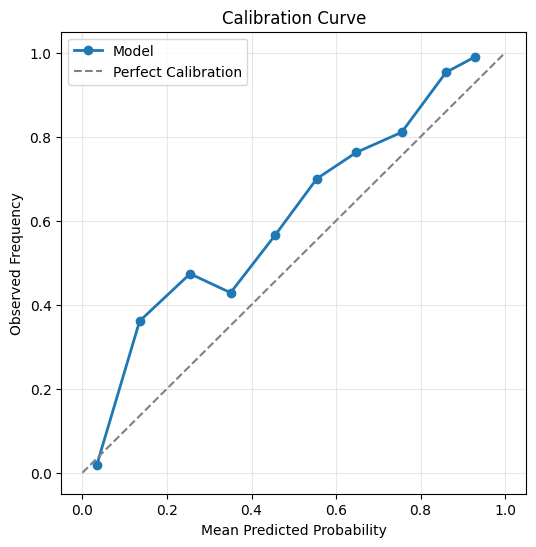

Calibration Analysis
Brier Score : 0.0557
ECE         : 0.0583


In [33]:
# ============================================================
# Calibration Analysis
# Brier Score + ECE + Reliability Diagram
# Positive class = Melanoma (label=1)
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import brier_score_loss
from sklearn.calibration import calibration_curve


# ------------------------------------------------------------
# Expected Calibration Error (ECE)
# ------------------------------------------------------------

def expected_calibration_error(y_true, probs, n_bins=10):

    bins = np.linspace(0, 1, n_bins + 1)

    binids = np.digitize(probs, bins) - 1

    ece = 0.0

    for i in range(n_bins):

        mask = binids == i

        if np.sum(mask) == 0:
            continue

        acc = np.mean(y_true[mask])

        conf = np.mean(probs[mask])

        ece += np.abs(acc - conf) * np.sum(mask) / len(y_true)

    return ece


# ------------------------------------------------------------
# Calibration Analysis
# ------------------------------------------------------------

def calibration_analysis(
        y_true,
        y_probs,
        n_bins=10):

    probs = y_probs[:,1]

    # -----------------------------
    # Brier Score
    # -----------------------------

    brier = brier_score_loss(
        y_true,
        probs
    )

    # -----------------------------
    # ECE
    # -----------------------------

    ece = expected_calibration_error(
        y_true,
        probs,
        n_bins=n_bins
    )

    # -----------------------------
    # Calibration Curve
    # -----------------------------

    frac_pos, mean_pred = calibration_curve(
        y_true,
        probs,
        n_bins=n_bins,
        strategy="uniform"
    )

    # -----------------------------
    # Plot
    # -----------------------------

    plt.figure(figsize=(6,6))

    plt.plot(
        mean_pred,
        frac_pos,
        marker="o",
        linewidth=2,
        label="Model"
    )

    plt.plot(
        [0,1],
        [0,1],
        "--",
        color="gray",
        label="Perfect Calibration"
    )

    plt.xlabel("Mean Predicted Probability")
    plt.ylabel("Observed Frequency")
    plt.title("Calibration Curve")
    plt.legend()
    plt.grid(alpha=0.3)

    plt.show()

    # -----------------------------
    # Results Table
    # -----------------------------

    print("="*40)
    print("Calibration Analysis")
    print("="*40)
    print(f"Brier Score : {brier:.4f}")
    print(f"ECE         : {ece:.4f}")

    return brier, ece


# ============================================================
# Run
# ============================================================

brier, ece = calibration_analysis(
    y_true,
    y_probs,
    n_bins=10
)

**Error Categories**

In [34]:
import numpy as np
import pandas as pd

def error_category_analysis(
    y_true,
    y_pred,
    y_prob,
    positive_class=1,
    confident_threshold=0.90,
    borderline_margin=0.10
):
    """
    Error Category Analysis for binary melanoma classification.

    Parameters
    ----------
    y_true : array-like
    y_pred : array-like
    y_prob : probability of positive class (melanoma)
    positive_class : int
    confident_threshold : float
    borderline_margin : float
        Borderline region around threshold=0.5.
        Example:
            margin=0.10
            Borderline => probability between 0.40 and 0.60
    """

    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    y_prob = np.asarray(y_prob)

    df = pd.DataFrame({
        "true": y_true,
        "pred": y_pred,
        "prob": y_prob
    })

    ########################################
    # False Negatives
    ########################################

    fn = df[
        (df.true == positive_class) &
        (df.pred != positive_class)
    ].copy()

    ########################################
    # False Positives
    ########################################

    fp = df[
        (df.true != positive_class) &
        (df.pred == positive_class)
    ].copy()

    ########################################
    # Confidence of prediction
    ########################################

    # confidence = probability assigned
    # to predicted class

    fn["confidence"] = 1.0 - fn["prob"]      # predicted negative
    fp["confidence"] = fp["prob"]            # predicted positive

    ########################################
    # Confidently Wrong
    ########################################

    confident_fn = fn[
        fn["confidence"] >= confident_threshold
    ]

    confident_fp = fp[
        fp["confidence"] >= confident_threshold
    ]

    ########################################
    # Borderline Errors
    ########################################

    lower = 0.5 - borderline_margin
    upper = 0.5 + borderline_margin

    borderline_fn = fn[
        (fn["prob"] >= lower) &
        (fn["prob"] <= 0.5)
    ]

    borderline_fp = fp[
        (fp["prob"] >= 0.5) &
        (fp["prob"] <= upper)
    ]

    ########################################
    # Summary table
    ########################################

    summary = pd.DataFrame({
        "FN":[len(fn)],
        "FP":[len(fp)],
        "Confident FN":[len(confident_fn)],
        "Confident FP":[len(confident_fp)],
        "Borderline FN":[len(borderline_fn)],
        "Borderline FP":[len(borderline_fp)],
        "Mean FN Confidence":[
            round(fn["confidence"].mean(),3)
            if len(fn)>0 else np.nan
        ],
        "Mean FP Confidence":[
            round(fp["confidence"].mean(),3)
            if len(fp)>0 else np.nan
        ]
    })

    ########################################
    # Print
    ########################################

    print("="*70)
    print("Error Category Summary")
    print("="*70)

    print(summary.to_string(index=False))

    print("\n")

    print("Confident False Negatives:")
    print(confident_fn.head())

    print("\n")

    print("Confident False Positives:")
    print(confident_fp.head())

    return summary, fn, fp, confident_fn, confident_fp

In [35]:
summary, fn, fp, cfn, cfp = error_category_analysis(
    y_true,
    y_pred,
    y_probs[:, 1]      # Probability of melanoma
)

Error Category Summary
 FN  FP  Confident FN  Confident FP  Borderline FN  Borderline FP  Mean FN Confidence  Mean FP Confidence
 60  59            12             5             17              9                0.74               0.735


Confident False Negatives:
     true  pred      prob  confidence
137     1     0  0.073099    0.926901
498     1     0  0.098425    0.901575
589     1     0  0.099034    0.900966
646     1     0  0.035444    0.964556
819     1     0  0.090574    0.909425


Confident False Positives:
      true  pred      prob  confidence
44       0     1  0.914214    0.914214
114      0     1  0.909224    0.909224
371      0     1  0.931275    0.931275
1150     0     1  0.944791    0.944791
1675     0     1  0.932269    0.932269


**Confidence Interval لـ ROC-AUC (Bootstrap)**

In [36]:
# ============================================================
# Bootstrap Confidence Interval for ROC-AUC
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import roc_auc_score
from sklearn.utils import resample


def bootstrap_auc_ci(
        y_true,
        y_probs,
        n_bootstrap=2000,
        confidence=0.95,
        random_state=42):

    rng = np.random.RandomState(random_state)

    probs = y_probs[:,1]

    # Original ROC-AUC
    original_auc = roc_auc_score(y_true, probs)

    auc_scores = []

    for _ in range(n_bootstrap):

        idx = resample(
            np.arange(len(y_true)),
            replace=True,
            random_state=rng.randint(0, 1_000_000)
        )

        yt = y_true[idx]
        yp = probs[idx]

        # ROC-AUC requires both classes
        if len(np.unique(yt)) < 2:
            continue

        auc_scores.append(
            roc_auc_score(yt, yp)
        )

    auc_scores = np.array(auc_scores)

    alpha = (1-confidence)/2

    lower = np.percentile(
        auc_scores,
        alpha*100
    )

    upper = np.percentile(
        auc_scores,
        (1-alpha)*100
    )

    print("="*45)
    print("Bootstrap ROC-AUC Confidence Interval")
    print("="*45)
    print(f"Original ROC-AUC : {original_auc:.4f}")
    print(f"Bootstrap Mean   : {auc_scores.mean():.4f}")
    print(f"95% CI           : [{lower:.4f}, {upper:.4f}]")

    return original_auc, lower, upper, auc_scores


# ============================================================
# Run
# ============================================================

auc, ci_low, ci_high, auc_boot = bootstrap_auc_ci(
    y_true,
    y_probs,
    n_bootstrap=2000,
    confidence=0.95,
    random_state=42
)

Bootstrap ROC-AUC Confidence Interval
Original ROC-AUC : 0.9796
Bootstrap Mean   : 0.9796
95% CI           : [0.9734, 0.9850]


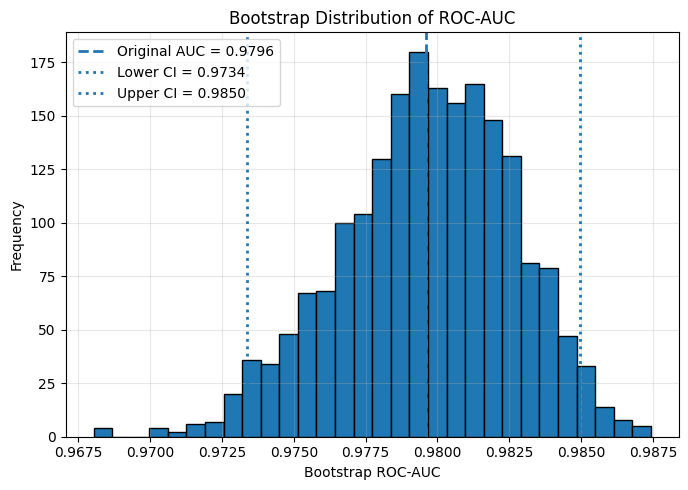

In [37]:
plt.figure(figsize=(7,5))

plt.hist(
    auc_boot,
    bins=30,
    edgecolor="black"
)

plt.axvline(
    auc,
    linestyle="--",
    linewidth=2,
    label=f"Original AUC = {auc:.4f}"
)

plt.axvline(
    ci_low,
    linestyle=":",
    linewidth=2,
    label=f"Lower CI = {ci_low:.4f}"
)

plt.axvline(
    ci_high,
    linestyle=":",
    linewidth=2,
    label=f"Upper CI = {ci_high:.4f}"
)

plt.xlabel("Bootstrap ROC-AUC")
plt.ylabel("Frequency")
plt.title("Bootstrap Distribution of ROC-AUC")

plt.grid(alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

In [38]:
from sklearn.metrics import accuracy_score, roc_auc_score
from sklearn.utils import resample
import numpy as np


def bootstrap_ci(
    y_true,
    y_pred,
    y_prob,
    metric="accuracy",
    n_bootstrap=2000,
    confidence=0.95,
    random_state=42
):

    rng = np.random.RandomState(random_state)

    scores = []

    for _ in range(n_bootstrap):

        idx = resample(
            np.arange(len(y_true)),
            replace=True,
            random_state=rng.randint(0, 1_000_000)
        )

        yt = y_true[idx]

        if metric == "accuracy":

            yp = y_pred[idx]
            score = accuracy_score(yt, yp)

        elif metric == "auc":

            # ROC-AUC يحتاج وجود الفئتين
            if len(np.unique(yt)) < 2:
                continue

            prob = y_prob[idx]
            score = roc_auc_score(yt, prob)

        else:
            raise ValueError("metric must be 'accuracy' or 'auc'")

        scores.append(score)

    scores = np.array(scores)

    alpha = (1 - confidence) / 2

    return {
        metric.capitalize():
            metric == "accuracy" and accuracy_score(y_true, y_pred)
            or roc_auc_score(y_true, y_prob),

        "Lower CI": np.percentile(scores, alpha * 100),

        "Upper CI": np.percentile(scores, (1 - alpha) * 100)
    }

In [39]:
accuracy_ci = bootstrap_ci(
    y_true=y_true,
    y_pred=y_pred,
    y_prob=y_probs[:,1],
    metric="accuracy"
)

print(accuracy_ci)

{'Accuracy': 0.9307334109429569, 'Lower CI': np.float64(0.9185098952270081), 'Upper CI': np.float64(0.9417927823050058)}


In [40]:
auc_ci = bootstrap_ci(
    y_true=y_true,
    y_pred=y_pred,
    y_prob=y_probs[:,1],
    metric="auc"
)

print(auc_ci)

{'Auc': np.float64(0.9796066272461987), 'Lower CI': np.float64(0.9733754718355775), 'Upper CI': np.float64(0.9849560084193345)}


De****cision Curve Analysis (Net Benefit)****

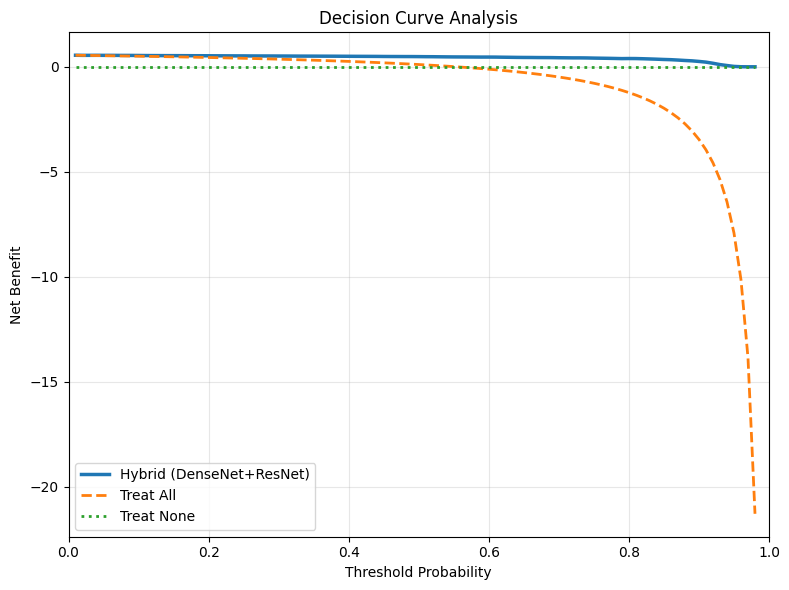

In [41]:
# ============================================================
# Decision Curve Analysis (Net Benefit)
# ============================================================

import numpy as np
import matplotlib.pyplot as plt


def decision_curve_analysis(
        y_true,
        y_probs,
        thresholds=np.arange(0.01,0.99,0.01)):

    probs = y_probs[:,1]

    N = len(y_true)

    prevalence = np.mean(y_true)

    net_benefit_model = []
    net_benefit_all = []

    for pt in thresholds:

        pred = probs >= pt

        TP = np.sum((pred == 1) & (y_true == 1))
        FP = np.sum((pred == 1) & (y_true == 0))

        # Model Net Benefit
        NB_model = (TP / N) - (FP / N) * (pt / (1 - pt))
        net_benefit_model.append(NB_model)

        # Treat All Strategy
        NB_all = prevalence - (1 - prevalence) * (pt / (1 - pt))
        net_benefit_all.append(NB_all)

    # Treat None
    net_benefit_none = np.zeros_like(thresholds)

    # --------------------------------------------------------

    plt.figure(figsize=(8,6))

    plt.plot(
        thresholds,
        net_benefit_model,
        linewidth=2.5,
        label="Hybrid (DenseNet+ResNet)"
    )

    plt.plot(
        thresholds,
        net_benefit_all,
        '--',
        linewidth=2,
        label="Treat All"
    )

    plt.plot(
        thresholds,
        net_benefit_none,
        ':',
        linewidth=2,
        label="Treat None"
    )

    plt.xlabel("Threshold Probability")
    plt.ylabel("Net Benefit")

    plt.title("Decision Curve Analysis")

    plt.xlim(0.0,1.0)

    plt.grid(alpha=0.3)

    plt.legend()

    plt.tight_layout()

    plt.show()

    return {
        "Threshold":thresholds,
        "Model NB":net_benefit_model,
        "Treat All NB":net_benefit_all
    }


# ============================================================
# Run
# ============================================================

dca_results = decision_curve_analysis(
    y_true,
    y_probs
)

In [42]:
# ============================================================
# Decision Curve Analysis (Net Benefit Table)
# ============================================================

import numpy as np
import pandas as pd


def decision_curve_table(
    y_true,
    y_probs,
    thresholds=np.arange(0.01, 1.00, 0.01)
):
    """
    Compute Decision Curve Analysis (Net Benefit).

    Parameters
    ----------
    y_true : ndarray
        Ground-truth labels (0=nevus, 1=melanoma)

    y_probs : ndarray
        Softmax probabilities with shape (N,2)

    thresholds : iterable
        Threshold probabilities

    Returns
    -------
    DataFrame
    """

    probs = y_probs[:, 1]

    N = len(y_true)
    prevalence = np.mean(y_true)

    results = []

    for pt in thresholds:

        pred = (probs >= pt)

        TP = np.sum((pred == 1) & (y_true == 1))
        FP = np.sum((pred == 1) & (y_true == 0))

        # Model Net Benefit
        nb_model = (TP / N) - (FP / N) * (pt / (1 - pt))

        # Treat All
        nb_all = prevalence - (1 - prevalence) * (pt / (1 - pt))

        # Treat None
        nb_none = 0.0

        results.append([
            pt,
            nb_model,
            nb_all,
            nb_none
        ])

    df = pd.DataFrame(
        results,
        columns=[
            "Threshold",
            "Model",
            "Treat All",
            "Treat None"
        ]
    )

    return df


# ============================================================
# Run
# ============================================================

dca_df = decision_curve_table(y_true, y_probs)

display(dca_df.round(6))

,Threshold,Model,Treat All,Treat None
0,0.01,0.549629,0.549629,0.0
1,0.02,0.545045,0.545033,0.0
2,0.03,0.545960,0.540343,0.0
3,0.04,0.547051,0.535555,0.0
4,0.05,0.545647,0.530666,0.0
...,...,...,...,...
94,0.95,0.019208,-7.917346,0.0
95,0.96,0.002328,-10.146682,0.0
96,0.97,0.000000,-13.862243,0.0
97,0.98,0.000000,-21.293364,0.0


**Reliability Diagram + Histogram**

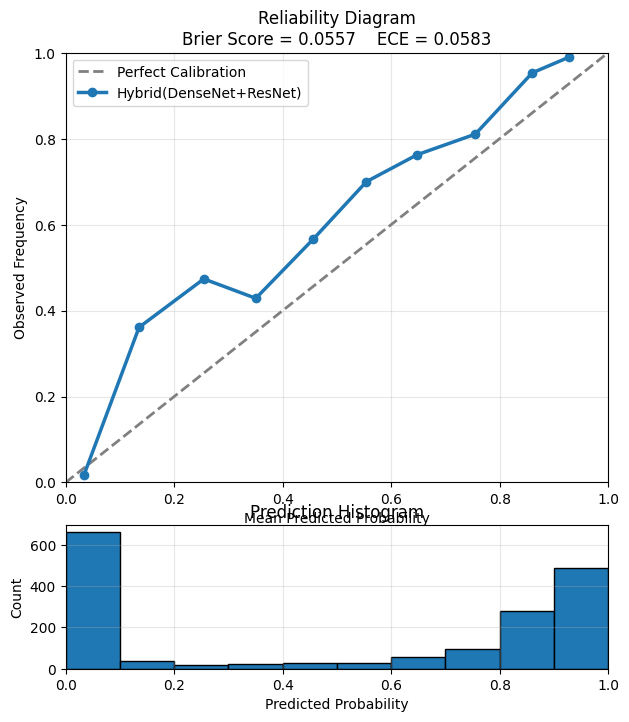

Calibration Metrics
Brier Score : 0.0557
ECE         : 0.0583
{'Brier Score': np.float64(0.055669980931663164), 'ECE': np.float64(0.05828458371727237)}


In [43]:
# ============================================================
# Reliability Diagram + Prediction Histogram
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss


def expected_calibration_error(y_true, probs, n_bins=10):

    bins = np.linspace(0, 1, n_bins + 1)

    bin_ids = np.digitize(probs, bins) - 1

    ece = 0.0

    for i in range(n_bins):

        mask = bin_ids == i

        if np.sum(mask) == 0:
            continue

        accuracy = np.mean(y_true[mask])

        confidence = np.mean(probs[mask])

        ece += (np.sum(mask) / len(y_true)) * abs(accuracy - confidence)

    return ece


def reliability_diagram(
        y_true,
        y_probs,
        n_bins=10):

    probs = y_probs[:,1]

    # --------------------------
    # Metrics
    # --------------------------

    brier = brier_score_loss(y_true, probs)

    ece = expected_calibration_error(
        y_true,
        probs,
        n_bins=n_bins
    )

    # --------------------------
    # Calibration Curve
    # --------------------------

    frac_pos, mean_pred = calibration_curve(
        y_true,
        probs,
        n_bins=n_bins,
        strategy="uniform"
    )

    # --------------------------
    # Figure
    # --------------------------

    fig = plt.figure(figsize=(7,8))

    gs = fig.add_gridspec(
        2,
        1,
        height_ratios=[3,1],
        hspace=0.15
    )

    # =====================================
    # Reliability Diagram
    # =====================================

    ax1 = fig.add_subplot(gs[0])

    ax1.plot(
        [0,1],
        [0,1],
        "--",
        color="gray",
        linewidth=2,
        label="Perfect Calibration"
    )

    ax1.plot(
        mean_pred,
        frac_pos,
        marker="o",
        linewidth=2.5,
        label="Hybrid(DenseNet+ResNet)"
    )

    ax1.set_xlim(0,1)
    ax1.set_ylim(0,1)

    ax1.set_xlabel("Mean Predicted Probability")
    ax1.set_ylabel("Observed Frequency")

    ax1.set_title(
        f"Reliability Diagram\n"
        f"Brier Score = {brier:.4f}    "
        f"ECE = {ece:.4f}"
    )

    ax1.grid(alpha=0.3)

    ax1.legend()

    # =====================================
    # Histogram
    # =====================================

    ax2 = fig.add_subplot(gs[1])

    ax2.hist(
        probs,
        bins=n_bins,
        range=(0,1),
        edgecolor="black"
    )

    ax2.set_xlim(0,1)

    ax2.set_xlabel("Predicted Probability")

    ax2.set_ylabel("Count")

    ax2.set_title("Prediction Histogram")

    ax2.grid(alpha=0.3)

    plt.tight_layout()

    plt.show()

    print("="*45)
    print("Calibration Metrics")
    print("="*45)
    print(f"Brier Score : {brier:.4f}")
    print(f"ECE         : {ece:.4f}")

    return {
        "Brier Score": brier,
        "ECE": ece
    }


# ============================================================
# Run
# ============================================================

calibration_results = reliability_diagram(
    y_true,
    y_probs,
    n_bins=10
)

print(calibration_results)


Per-class Confidence Interval****

In [44]:
# ============================================================
# Per-Class Bootstrap Confidence Intervals
# ============================================================

import numpy as np
import pandas as pd

from sklearn.metrics import precision_recall_fscore_support
from sklearn.utils import resample


def per_class_bootstrap_ci(
    y_true,
    y_pred,
    n_bootstrap=2000,
    confidence=0.95,
    random_state=42
):

    rng = np.random.RandomState(random_state)

    metrics = {
        "Melanoma": {
            "Precision": [],
            "Recall": [],
            "F1": []
        },
        "Nevus": {
            "Precision": [],
            "Recall": [],
            "F1": []
        }
    }

    N = len(y_true)

    for _ in range(n_bootstrap):

        idx = resample(
            np.arange(N),
            replace=True,
            random_state=rng.randint(0, 1_000_000)
        )

        yt = y_true[idx]
        yp = y_pred[idx]

        if len(np.unique(yt)) < 2:
            continue

        precision, recall, f1, _ = precision_recall_fscore_support(
            yt,
            yp,
            labels=[1,0],      # Melanoma ثم Nevus
            zero_division=0
        )

        metrics["Melanoma"]["Precision"].append(precision[0])
        metrics["Melanoma"]["Recall"].append(recall[0])
        metrics["Melanoma"]["F1"].append(f1[0])

        metrics["Nevus"]["Precision"].append(precision[1])
        metrics["Nevus"]["Recall"].append(recall[1])
        metrics["Nevus"]["F1"].append(f1[1])

    alpha = (1-confidence)/2

    rows = []

    # Original metrics
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true,
        y_pred,
        labels=[1,0],
        zero_division=0
    )

    original = {
        "Melanoma": {
            "Precision": precision[0],
            "Recall": recall[0],
            "F1": f1[0]
        },
        "Nevus": {
            "Precision": precision[1],
            "Recall": recall[1],
            "F1": f1[1]
        }
    }

    for cls in ["Melanoma", "Nevus"]:

        for metric in ["Precision", "Recall", "F1"]:

            values = np.array(metrics[cls][metric])

            rows.append({

                "Class": cls,

                "Metric": metric,

                "Value": original[cls][metric],

                "Lower 95% CI": np.percentile(values, alpha*100),

                "Upper 95% CI": np.percentile(values, (1-alpha)*100)

            })

    return pd.DataFrame(rows)

In [45]:
per_class_ci = per_class_bootstrap_ci(
    y_true,
    y_pred,
    n_bootstrap=2000
)

display(per_class_ci.round(4))

,Class,Metric,Value,Lower 95% CI,Upper 95% CI
0,Melanoma,Precision,0.9380,0.9220,0.9521
1,Melanoma,Recall,0.9370,0.9215,0.9514
2,Melanoma,F1,0.9375,0.9255,0.9476
3,Nevus,Precision,0.9218,0.9023,0.9393
4,Nevus,Recall,0.9230,0.9039,0.9406
5,Nevus,F1,0.9224,0.9080,0.9350


## Part 9 — Model Summary

We report the model's parameter counts, per-image inference latency (averaged over multiple
runs on the test set, GPU-synchronized for accurate timing), GPU information, and on-disk
model size.


In [ ]:
# ----------------------------- Parameter counts -----------------------------
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
non_trainable_params = total_params - trainable_params

print(f"Total parameters:         {total_params:,}")
print(f"Trainable parameters:     {trainable_params:,}")
print(f"Non-trainable parameters: {non_trainable_params:,}")


In [ ]:
# ----------------------------- Inference time per image -----------------------------

@torch.no_grad()
def measure_inference_time(model, loader, n_warmup_batches=3, n_timed_batches=20):
    '''
    Measures average per-image inference latency.
    GPU calls are asynchronous, so we explicitly call torch.cuda.synchronize() around
    timing to get accurate wall-clock measurements.
    '''
    model.eval()
    loader_iter = iter(loader)

    # Warm-up (excluded from timing -- first few batches include CUDA kernel compilation/caching)
    for _ in range(n_warmup_batches):
        try:
            images, _ = next(loader_iter)
        except StopIteration:
            loader_iter = iter(loader)
            images, _ = next(loader_iter)
        images = images.to(DEVICE)
        _ = model(images)

    if torch.cuda.is_available():
        torch.cuda.synchronize()

    total_images = 0
    total_time = 0.0
    loader_iter = iter(loader)
    for i in range(n_timed_batches):
        try:
            images, _ = next(loader_iter)
        except StopIteration:
            break

        images = images.to(DEVICE)
        if torch.cuda.is_available():
            torch.cuda.synchronize()
        t0 = time.time()

        _ = model(images)

        if torch.cuda.is_available():
            torch.cuda.synchronize()
        t1 = time.time()

        total_time += (t1 - t0)
        total_images += images.size(0)

    return (total_time / total_images) * 1000  # ms per image


avg_inference_ms = measure_inference_time(model, test_loader)
print(f"Average inference time per image: {avg_inference_ms:.3f} ms")


In [ ]:
# ----------------------------- GPU information -----------------------------
if torch.cuda.is_available():
    gpu_name = torch.cuda.get_device_name(0)
    gpu_props = torch.cuda.get_device_properties(0)
    gpu_total_mem_gb = gpu_props.total_memory / (1024 ** 3)
    gpu_mem_allocated_gb = torch.cuda.memory_allocated(0) / (1024 ** 3)
    gpu_mem_reserved_gb = torch.cuda.memory_reserved(0) / (1024 ** 3)

    print(f"GPU Name:               {gpu_name}")
    print(f"CUDA Capability:        {gpu_props.major}.{gpu_props.minor}")
    print(f"Total GPU Memory:       {gpu_total_mem_gb:.2f} GB")
    print(f"Currently Allocated:    {gpu_mem_allocated_gb:.2f} GB")
    print(f"Currently Reserved:     {gpu_mem_reserved_gb:.2f} GB")
else:
    gpu_name = "N/A (CPU only)"
    print("No GPU detected -- running on CPU.")


In [ ]:
# ----------------------------- Model size on disk -----------------------------
model_size_bytes = best_model_path.stat().st_size
model_size_mb = model_size_bytes / (1024 ** 2)
print(f"Saved model checkpoint size: {model_size_mb:.2f} MB  ({best_model_path})")


In [ ]:
# ----------------------------- Consolidated model summary -----------------------------
model_summary = {
    "total_parameters": int(total_params),
    "trainable_parameters": int(trainable_params),
    "non_trainable_parameters": int(non_trainable_params),
    "avg_inference_time_ms_per_image": round(avg_inference_ms, 3),
    "gpu": gpu_name,
    "model_checkpoint_size_mb": round(model_size_mb, 2),
}

print(json.dumps(model_summary, indent=2))


## Part 10 — Save Results

Every figure, metric file, and prediction table generated throughout this notebook has already
been written incrementally into the `results/` folder as it was produced (rather than held in
memory until the end, which would risk losing everything on a crash). This section performs a
final consolidation pass: writing the model summary to disk and printing the complete `results/`
directory tree so it's easy to confirm everything required by the project spec is present.

> **Kaggle-specific note — files only persist if you commit the notebook.** Everything under
> `/kaggle/working/results/` exists only inside the *live session* while you're running cells
> interactively. Kaggle's **Output** panel (and the ability to download these files later) only
> gets populated after you click **Save Version** (top-right) and let it run as a committed
> version — ideally with **"Save & Run All (Commit)"** so it re-executes the whole notebook
> top-to-bottom in a fresh session and snapshots everything `/kaggle/working` contains at the
> end. If you only ran cells live in Edit mode and never committed a version, the Output panel
> will stay empty (as you've likely seen) even though the files were genuinely created during
> your session.


In [ ]:
# ----------------------------- Save model summary to disk -----------------------------
with open(RESULTS_DIR / "model_summary.json", "w") as f:
    json.dump(model_summary, f, indent=2)

with open(RESULTS_DIR / "config.json", "w") as f:
    json.dump(CONFIG, f, indent=2)

print(f"Saved: {RESULTS_DIR / 'model_summary.json'}")
print(f"Saved: {RESULTS_DIR / 'config.json'}")


In [ ]:
# ----------------------------- Save training history -----------------------------
history_df = pd.DataFrame(history)
history_df.insert(0, "epoch", range(1, len(history_df) + 1))
history_df.to_csv(RESULTS_DIR / "training_history.csv", index=False)
print(f"Saved: {RESULTS_DIR / 'training_history.csv'}")


In [ ]:
# ----------------------------- Final results/ directory tree -----------------------------

def print_directory_tree(root: Path, prefix: str = ""):
    entries = sorted(root.iterdir(), key=lambda p: (p.is_file(), p.name))
    for i, entry in enumerate(entries):
        connector = "└── " if i == len(entries) - 1 else "├── "
        print(f"{prefix}{connector}{entry.name}")
        if entry.is_dir():
            extension = "    " if i == len(entries) - 1 else "│   "
            print_directory_tree(entry, prefix + extension)

print(f"{RESULTS_DIR}/")
print_directory_tree(RESULTS_DIR)


## Summary

This notebook implemented a complete, end-to-end pipeline for multi-class skin cancer
classification on the 9-class ISIC dataset using a **DenseNet121 + ResNet50 feature-fusion
hybrid CNN**, covering data preparation, model architecture, training with mixed precision and
early stopping, a comprehensive clinical evaluation metric suite, full visualization of model
performance, Grad-CAM explainability for both backbone branches, t-SNE/UMAP feature-space
visualization, detailed error analysis, model efficiency reporting, and a structured `results/`
output folder ready for inclusion in a graduation project report or defense presentation.
